<h1>IMU File Reading </h1>

In [5]:
from pathlib import Path

DERIVED_ROOT = Path("--")

imu_files = list(DERIVED_ROOT.rglob("imu/**/*.csv"))
print("IMU files found:", len(imu_files))
print("first 10:", [str(p) for p in imu_files[:10]])


IMU files found: 152
first 10: ['/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/Abhay/imu/numerical/abhay_raint_d3.csv', '/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/Abhay/imu/numerical/abhay_raint_d2.csv', '/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/Abhay/imu/numerical/abhay_raint_d1.csv', '/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/Abhay/imu/rest/abhay_rest_d1.csv', '/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/Abhay/imu/rest/abhay_rest_d2.csv', '/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/Abhay/imu/rest/abhay_rest_d3.csv', '/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/Abhay/imu/rest/abhay_rest_d1_blue.csv', '/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/Abhay/imu/rest/.ipynb_checkpoints/abhay_rest_d1-checkpoint.csv', '/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/Walid/imu/stroop/wlid_strd3.csv', '/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/Walid/imu/stroop/wlid_str_d2.csv']


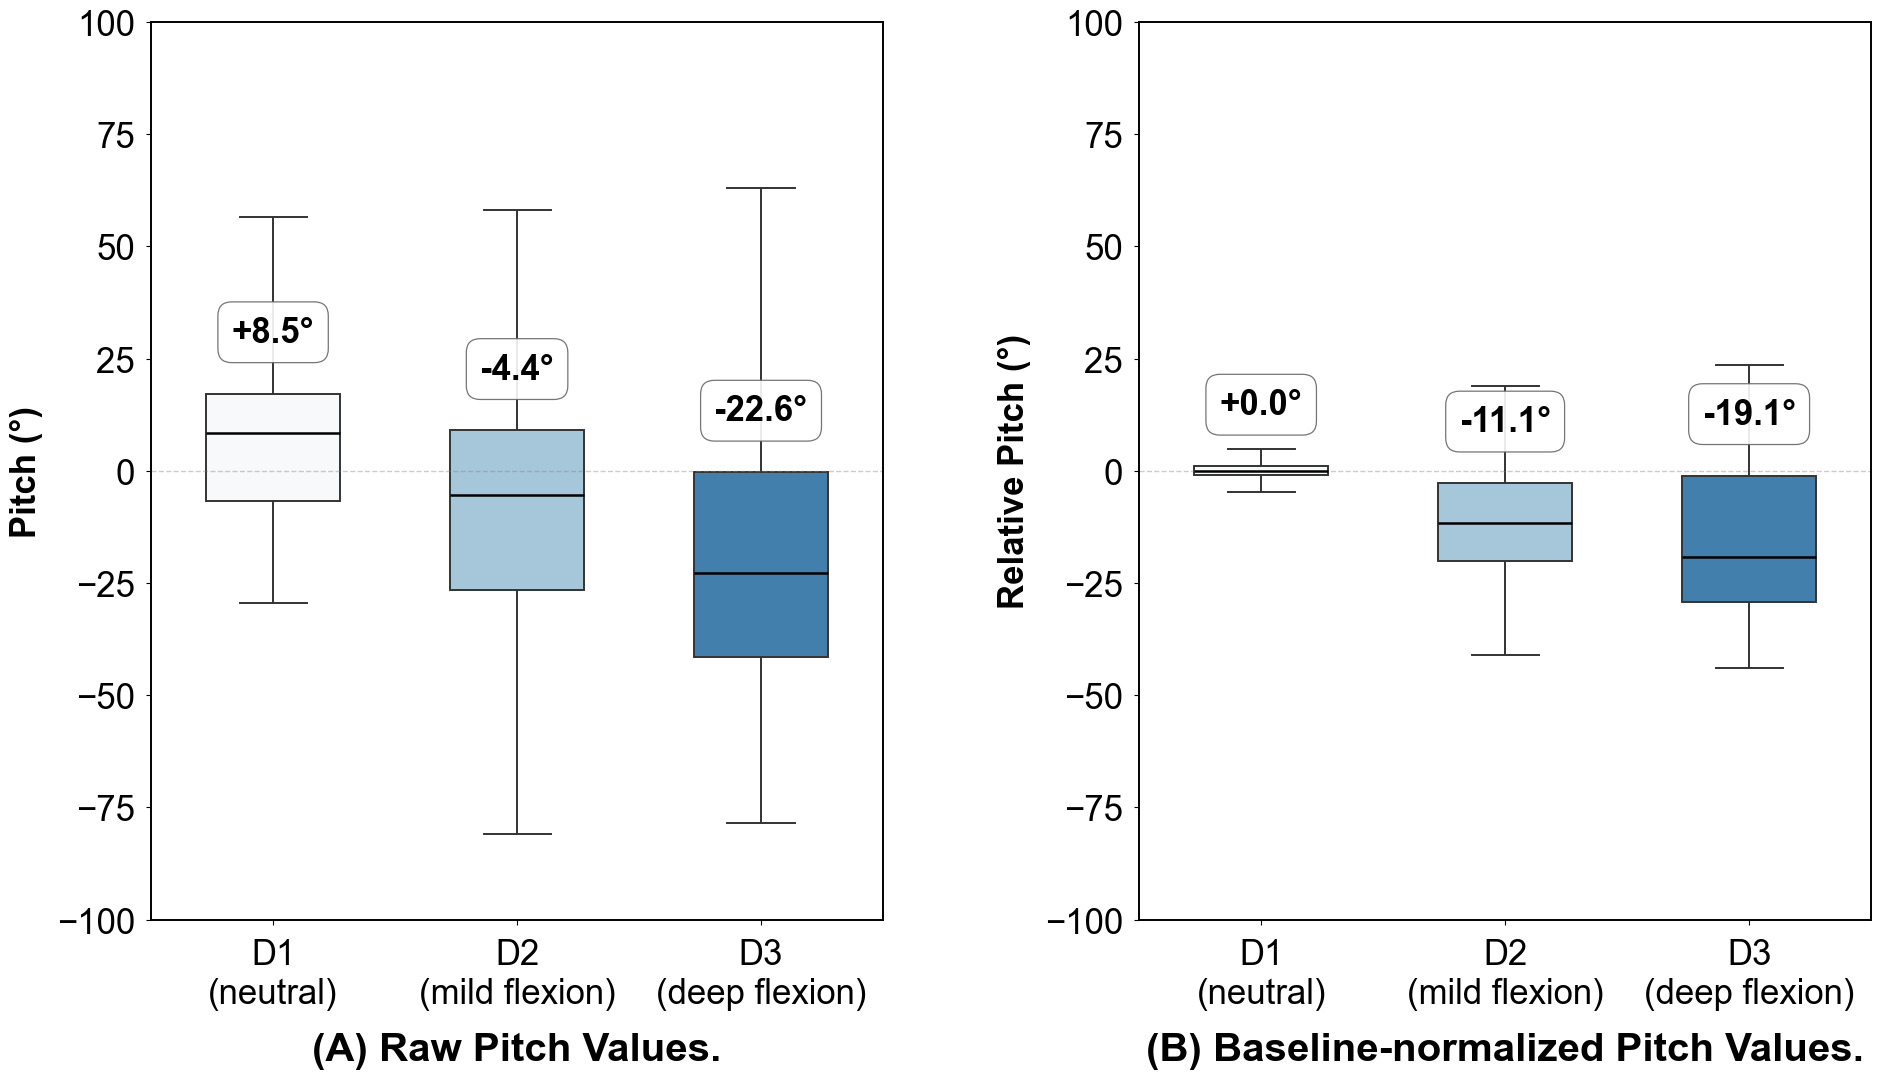

In [175]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ══════════════════════════════════════════════════════════════════
# REPLACE THIS BLOCK with your real df_norm when available
# ══════════════════════════════════════════════════════════════════
def build_exact(median, q1, q3, w_low, w_high, n=80, seed=0):
    rng = np.random.default_rng(seed)
    arr = np.concatenate([
        rng.uniform(w_low, q1,     n // 4),
        rng.uniform(q1,    median, n // 4),
        rng.uniform(median, q3,    n // 4),
        rng.uniform(q3,    w_high, n // 4),
    ])
    arr = np.sort(arr)
    arr[len(arr) // 2] = median
    return arr

d1_p = build_exact( 8.5,   -7,   18, -30,  58, seed=1)
d2_p = build_exact(-4.4,  -28,    9, -84,  60, seed=2)
d3_p = build_exact(-22.6, -41,    1, -82,  65, seed=3)
d1_r = build_exact( 0.0,   -1,    1,  -5,   5, seed=4)
d2_r = build_exact(-11.1, -20,   -3, -42,  19, seed=5)
d3_r = build_exact(-19.1, -30,   -2, -44,  24, seed=6)

rows = []
for post, sv, rv in [("d1", d1_p, d1_r),
                     ("d2", d2_p, d2_r),
                     ("d3", d3_p, d3_r)]:
    for s, r in zip(sv, rv):
        rows.append({"post": post, "sig": s, "norm_sig": r})
df_norm = pd.DataFrame(rows)
# ══════════════════════════════════════════════════════════════════

# ── Single unified font size (matches figure-caption size) ────────
F = 25  # <-- change this ONE value to scale everything together

plt.style.use("default")
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Arial", "DejaVu Sans"],
    "font.size":        F,
    "axes.labelsize":   F,
    "axes.labelweight": "bold",
    "xtick.labelsize":  F,
    "ytick.labelsize":  F,
    "pdf.fonttype":     42,
    "ps.fonttype":      42,
})

fig, axes = plt.subplots(1, 2, figsize=(20,14))
posture_order    = ["d1", "d2", "d3"]
academic_palette = ["#f8f9fa", "#9ecae1", "#3182bd"]

config = [
    ("sig",      "Pitch (°)",
     "(A) Raw Pitch Values.",
     ["+8.5°", "-4.4°", "-22.6°"]),
    ("norm_sig", "Relative Pitch (°)",
     "(B) Baseline-normalized Pitch Values.",
     ["+0.0°", "-11.1°", "-19.1°"]),
]

for i, (col_name, y_label, xlabel, annot_texts) in enumerate(config):
    ax = axes[i]

    long_df = df_norm[["post", col_name]].rename(columns={col_name: "val"}).copy()
    long_df["post"] = pd.Categorical(
        long_df["post"], categories=posture_order, ordered=True
    )

    sns.boxplot(
        data=long_df,
        x="post", y="val",
        order=posture_order,
        palette=academic_palette,
        showfliers=False,
        width=0.55,
        linewidth=1.4,
        whis=10,
        ax=ax,
        medianprops=  {"color": "black",     "linewidth": 1.8},
        boxprops=     {"edgecolor": "#333333","linewidth": 1.4},
        whiskerprops= {"color": "#333333",    "linewidth": 1.4},
        capprops=     {"color": "#333333",    "linewidth": 1.4},
        hue="post",
        legend=False,
    )

    ax.set_ylim(-100, 100)
    ax.set_ylabel(y_label, fontweight="bold", labelpad=10, fontsize=F)
    ax.set_xlabel(xlabel,  fontweight="bold", labelpad=16,
                  linespacing=1.5, fontsize=F+4)

    ax.set_xticks(range(3))
    ax.set_xticklabels([
        "D1\n(neutral)",
        "D2\n(mild flexion)",
        "D3\n(deep flexion)"
    ], fontsize=F)
    ax.tick_params(axis="x", pad=10, labelsize=F)
    ax.tick_params(axis="y", pad=8,  labelsize=F)

    ax.set_facecolor("white")
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(1.4)

    ax.axhline(0, color="gray", linestyle="--", linewidth=1.0, alpha=0.4)

    # ── annotation badges — same F size as everything else ────────
    for j, post in enumerate(posture_order):
        vals    = long_df.loc[long_df["post"] == post, "val"]
        q3      = vals.quantile(0.75)
        label_y = min(q3 + 10, 100 - 16)   # headroom for larger badge

        ax.text(
            j, label_y,
            annot_texts[j],
            ha="center", va="bottom",
            fontsize=F,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.40",
                facecolor="white",
                edgecolor="#666666",
                linewidth=0.9,
                alpha=0.9,
            ),
            clip_on=False,
        )

plt.tight_layout(pad=2.0)
fig.subplots_adjust(bottom=0.30, wspace=0.35)

# ── Save ──────────────────────────────────────────────────────────
save_path = "/Users/sgomasta/Desktop/Tech Neck Coding/Final Code_MobileHCI/posture_boxplots"
plt.savefig(save_path + ".png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(save_path + ".pdf", format="pdf",  bbox_inches="tight", facecolor="white")
plt.show()

<h1> participant baseline problem </h1>

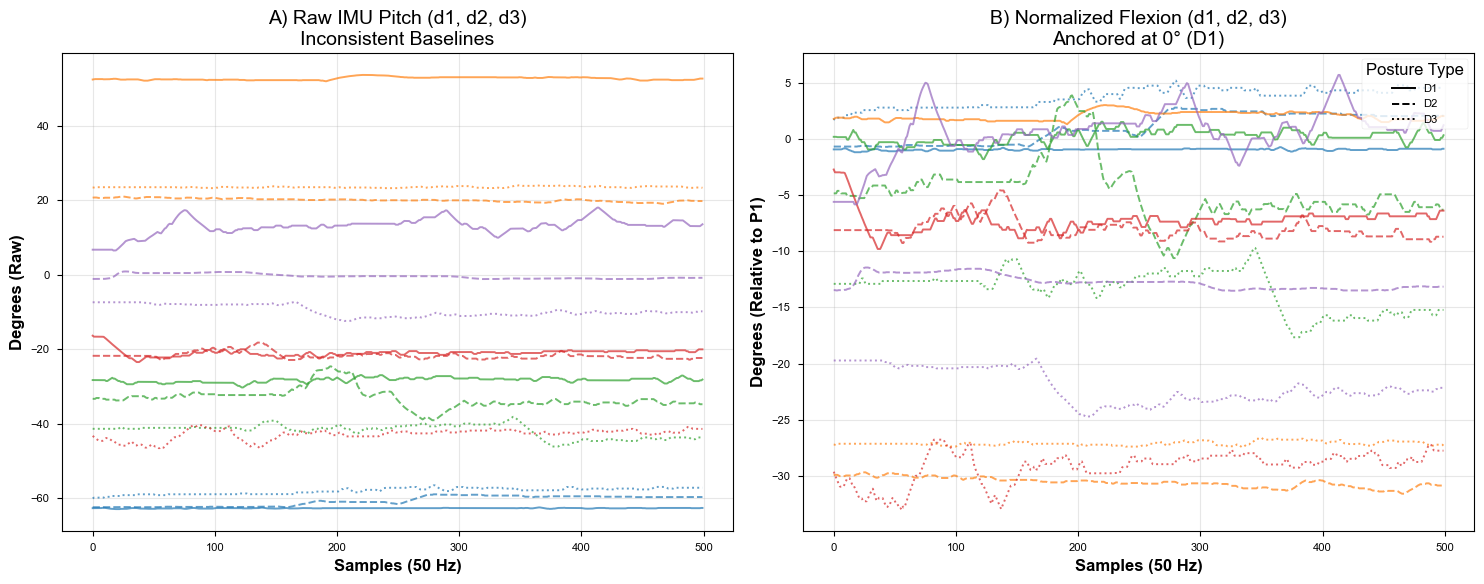

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_posture_calibration_academic(df_norm):
    """
    Plots Raw vs Normalized pitch for d1, d2, and d3 across 5 participants.
    """
    plt.style.use('seaborn-v0_8-paper')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
    
    # Select 5 participants for the visualization
    sample_ppts = df_norm['p'].unique()[:5]
    colors = sns.color_palette("tab10", n_colors=len(sample_ppts))
    posture_styles = {'d1': '-', 'd2': '--', 'd3': ':'}
    
    for i, ppt in enumerate(sample_ppts):
        color = colors[i]
        for post in ['d1', 'd2', 'd3']:
            subset = df_norm[(df_norm['p'] == ppt) & (df_norm['post'] == post)]
            if subset.empty: continue
            
            # Plot first 500 samples (10 seconds)
            # Left: Raw signals showing scatter
            ax1.plot(subset.iloc[0]['sig'][:500], 
                     color=color, linestyle=posture_styles[post], alpha=0.7)
            
            # Right: Normalized signals showing alignment
            ax2.plot(subset.iloc[0]['norm_sig'][:500], 
                     color=color, linestyle=posture_styles[post], alpha=0.7)

    # Custom Legend for Posture Types
    from matplotlib.lines import Line2D
    posture_legend = [Line2D([0], [0], color='black', linestyle=posture_styles[p], label=p.upper()) 
                      for p in ['d1', 'd2', 'd3']]
    
    ax1.set_title("A) Raw IMU Pitch (d1, d2, d3)\nInconsistent Baselines", fontsize=14)
    ax1.set_ylabel("Degrees (Raw)", fontsize=12)
    ax1.set_xlabel("Samples (50 Hz)", fontsize=12)
    ax1.grid(True, alpha=0.3)

    ax2.set_title("B) Normalized Flexion (d1, d2, d3)\nAnchored at 0° (D1)", fontsize=14)
    ax2.set_ylabel("Degrees (Relative to P1)", fontsize=12)
    ax2.set_xlabel("Samples (50 Hz)", fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    ax2.legend(handles=posture_legend, title="Posture Type", loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Run this after load_and_normalize()
plot_posture_calibration_academic(df_norm)

<h1>Feature Extraction </h1>

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_posture_calibration_4panels(df_norm):
   
    
    plt.style.use("seaborn-v0_8-paper")
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Explicit posture order (CRITICAL)
    posture_order = ["d1", "d2", "d3"]

    # Color per participant (consistent across panels)
    participants = df_norm["p"].unique()
    palette = sns.color_palette("tab10", n_colors=len(participants))
    color_map = {p: palette[i % len(palette)] for i, p in enumerate(participants)}

  
    for _, row in df_norm.iterrows():
        axes[0, 0].plot(
            row["sig"],
            color=color_map[row["p"]],
            alpha=0.25,
            linewidth=0.8
        )

    axes[0, 0].set_title("(A) Raw Pitch: Participant-Specific Offsets", fontweight="bold")
    axes[0, 0].set_ylabel("Pitch (deg)")
    axes[0, 0].set_xlabel("Time (samples @ 50 Hz)")
    axes[0, 0].axhline(0, linestyle="--", color="gray", alpha=0.5)
    axes[0, 0].grid(alpha=0.3)

    
    for _, row in df_norm.iterrows():
        axes[0, 1].plot(
            row["norm_sig"],
            color=color_map[row["p"]],
            alpha=0.25,
            linewidth=0.8
        )

    axes[0, 1].set_title("(B) Normalized Flexion: D1 Anchored at 0°", fontweight="bold")
    axes[0, 1].set_ylabel("Relative Pitch (deg)")
    axes[0, 1].set_xlabel("Time (samples @ 50 Hz)")
    axes[0, 1].axhline(0, linestyle="--", color="gray", alpha=0.5)
    axes[0, 1].grid(alpha=0.3)

    # --------------------------------------------------
    # Prepare long-format data for distributions
    # --------------------------------------------------
    raw_long = pd.concat(
        [pd.DataFrame({"post": r["post"], "val": r["sig"]})
         for _, r in df_norm.iterrows()],
        ignore_index=True
    )

    norm_long = pd.concat(
        [pd.DataFrame({"post": r["post"], "val": r["norm_sig"]})
         for _, r in df_norm.iterrows()],
        ignore_index=True
    )

    # Enforce categorical ordering (IMPORTANT)
    cat_type = pd.CategoricalDtype(categories=posture_order, ordered=True)
    raw_long["post"] = raw_long["post"].astype(cat_type)
    norm_long["post"] = norm_long["post"].astype(cat_type)

    sns.boxplot(
        data=raw_long,
        x="post",
        y="val",
        order=posture_order,
        showfliers=False,
        palette="muted",
        ax=axes[1, 0]
    )

    axes[1, 0].set_title("(C) Raw Pitch Distribution Across Postures", fontweight="bold")
    axes[1, 0].set_xlabel("Posture")
    axes[1, 0].set_ylabel("Pitch (deg)")
    axes[1, 0].axhline(0, linestyle="--", color="gray", alpha=0.5)
    axes[1, 0].grid(axis="y", alpha=0.3)

    # --------------------------------------------------
    # (D) Normalized distribution
    # --------------------------------------------------
    sns.boxplot(
        data=norm_long,
        x="post",
        y="val",
        order=posture_order,
        showfliers=False,
        palette="muted",
        ax=axes[1, 1]
    )

    axes[1, 1].set_title("(D) Normalized Distribution (D1 Anchored at 0°)", fontweight="bold")
    axes[1, 1].set_xlabel("Posture")
    axes[1, 1].set_ylabel("Relative Pitch (deg)")
    axes[1, 1].axhline(0, linestyle="--", color="gray", alpha=0.5)
    axes[1, 1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


In [16]:


sanity = []
for (p, t), g in df_norm.groupby(["p", "t"]):
    d1 = g[g["post"]=="d1"]
    if d1.empty: 
        continue
    d1_vals = np.concatenate(d1["norm_sig"].values)
    sanity.append([p, t, np.median(d1_vals), np.mean(d1_vals)])

sanity_df = pd.DataFrame(sanity, columns=["p","t","d1_median_norm","d1_mean_norm"])
print(sanity_df.sort_values(["t","p"]).to_string(index=False))


KeyError: 't'

In [ ]:
check = []
for (p, t), g in df_norm.groupby(["p", "t"]):
    d1 = g[g["post"]=="d1"]
    d3 = g[g["post"]=="d3"]
    if d1.empty or d3.empty:
        continue
    d3_vals = np.concatenate(d3["norm_sig"].values)
    check.append([p, t, np.median(d3_vals)])

check_df = pd.DataFrame(check, columns=["p","t","d3_median_norm"])
print(check_df.sort_values(["t","p"]).to_string(index=False))


In [ ]:
WINDOW_SEC = 5
OVERLAP = 0.5
win_len = int(WINDOW_SEC * IMU_FS)
step = int(win_len * (1 - OVERLAP))

features = []
for _, row in df_norm.iterrows():
    sig = row["norm_sig"]
    for start in range(0, len(sig) - win_len + 1, step):
        w = sig[start:start + win_len]
        features.append({
            "participant": row["p"], "label": row["post"],
            "mean": np.mean(w), "median": np.median(w), "std": np.std(w),
            "rms": np.sqrt(np.mean(w**2)), "range": np.ptp(w),
            "skew": skew(w), "kurt": kurtosis(w), "iqr": np.percentile(w, 75) - np.percentile(w, 25),
            "mav": np.mean(np.abs(np.diff(w))),
            "zcr": np.sum(np.diff(np.sign(w - np.mean(w))) != 0) / len(w)
        })

df_feat = pd.DataFrame(features)
print(f"Extracted {len(df_feat)} windows of 10 features each.")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
)
from sklearn.preprocessing import StandardScaler

# --- RF CONFIG ---
RF_CFG = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

def within_subject_8020(df_feat, y_array, labels, title):
    """
    80/20 split PER PARTICIPANT (no mixing across subjects, no window leakage).
    """
    X_cols = [c for c in df_feat.columns if c not in ["participant", "label"]]
    all_true, all_pred = [], []

    for pid in df_feat["participant"].unique():
        sub = df_feat[df_feat["participant"] == pid]
        if len(sub) < 5:
            continue

        X_sub = sub[X_cols].reset_index(drop=True)
        y_sub = y_array[sub.index].reset_index(drop=True)

        # deterministic 80/20 split without mixing subjects
        n = len(X_sub)
        split_idx = int(0.8 * n)
        X_tr, X_te = X_sub.iloc[:split_idx], X_sub.iloc[split_idx:]
        y_tr, y_te = y_sub.iloc[:split_idx], y_sub.iloc[split_idx:]

        if len(np.unique(y_tr)) < len(labels):
            continue

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        rf = RandomForestClassifier(**RF_CFG)
        rf.fit(X_tr_s, y_tr)
        y_hat = rf.predict(X_te_s)

        all_true.append(y_te.values)
        all_pred.append(y_hat)

    if not all_true:
        print(f"[{title} – 80/20] Not enough data per participant to evaluate.")
        return None, None, None

    all_true = np.concatenate(all_true)
    all_pred = np.concatenate(all_pred)

    acc = accuracy_score(all_true, all_pred)
    print(f"[{title} – 80/20 per‑subject] Accuracy: {acc:.3f}")
    print(classification_report(all_true, all_pred, target_names=labels))

    cm = confusion_matrix(all_true, all_pred)
    return cm, all_true, all_pred

def loso_subject_independent(df_feat, y_array, labels, title):
    """
    Leave-One-Subject-Out (LOSO): train on all but one participant, test on that participant.
    """
    X_cols = [c for c in df_feat.columns if c not in ["participant", "label"]]
    X = df_feat[X_cols].reset_index(drop=True)
    y = y_array.reset_index(drop=True)
    groups = df_feat["participant"].reset_index(drop=True)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    logo = LeaveOneGroupOut()
    y_true_all, y_pred_all = [], []

    for train_idx, test_idx in logo.split(X_scaled, y, groups):
        X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        if len(np.unique(y_tr)) < len(labels):
            continue

        rf = RandomForestClassifier(**RF_CFG)
        rf.fit(X_tr, y_tr)
        y_hat = rf.predict(X_te)

        y_true_all.append(y_te.values)
        y_pred_all.append(y_hat)

    if not y_true_all:
        print(f"[{title} – LOSO] Not enough class diversity in training folds.")
        return None, None, None

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    acc = accuracy_score(y_true_all, y_pred_all)
    print(f"[{title} – LOSO] Accuracy: {acc:.3f}")
    print(classification_report(y_true_all, y_pred_all, target_names=labels))

    cm = confusion_matrix(y_true_all, y_pred_all)
    return cm, y_true_all, y_pred_all

def plot_results(cm_8020, cm_loso, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    if cm_8020 is not None:
        sns.heatmap(cm_8020, annot=True, fmt="d", cmap="Blues",
                    xticklabels=labels, yticklabels=labels, ax=axes[0])
        axes[0].set_title(f"80/20 per‑subject: {title}")
        axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    if cm_loso is not None:
        sns.heatmap(cm_loso, annot=True, fmt="d", cmap="Greens",
                    xticklabels=labels, yticklabels=labels, ax=axes[1])
        axes[1].set_title(f"LOSO: {title}")
        axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    plt.tight_layout()
    plt.show()

def plot_top_features(df_feat, y_array, title, top_k=10):
    X_cols = [c for c in df_feat.columns if c not in ["participant", "label"]]
    X = df_feat[X_cols]
    y = y_array

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    rf = RandomForestClassifier(**RF_CFG)
    rf.fit(X_scaled, y)

    imp = pd.Series(rf.feature_importances_, index=X_cols).sort_values(ascending=False).head(top_k)

    plt.figure(figsize=(8, 4))
    imp.plot(kind="barh")
    plt.gca().invert_yaxis()
    plt.title(f"Top {top_k} Features – {title}")
    plt.xlabel("Feature importance")
    plt.tight_layout()
    plt.show()

# ---------------- RUNNING THE TASKS ----------------
# X and groups come from df_feat; features are all non‑ID, non‑label columns
X = df_feat.drop(columns=["participant", "label"])
groups = df_feat["participant"]

# Task A: Multi-Class posture (D1, D2, D3)
y_multi = df_feat["label"].map({"d1": 0, "d2": 1, "d3": 2})
labels_multi = ["D1", "D2", "D3"]

print("\n===== IMU MULTI-CLASS (D1/D2/D3) =====") 
cm_8020_m, _, _ = within_subject_8020(df_feat, y_multi, labels_multi, "IMU Multi-Class")
cm_loso_m, _, _ = loso_subject_independent(df_feat, y_multi, labels_multi, "IMU Multi-Class")
plot_results(cm_8020_m, cm_loso_m, labels_multi, "IMU Multi-Class")
plot_top_features(df_feat, y_multi, "IMU Multi-Class", top_k=10)

# Task B: Binary posture (D1 vs D2+D3)
y_bin = df_feat["label"].map({"d1": 0, "d2": 1, "d3": 1})
labels_bin = ["D1 (Good)", "Slouch (D2+D3)"]

print("\n===== IMU BINARY (D1 vs Slouch) =====")
cm_8020_b, _, _ = within_subject_8020(df_feat, y_bin, labels_bin, "IMU Binary")
cm_loso_b, _, _ = loso_subject_independent(df_feat, y_bin, labels_bin, "IMU Binary")
plot_results(cm_8020_b, cm_loso_b, labels_bin, "IMU Binary")
plot_top_features(df_feat, y_bin, "IMU Binary", top_k=10)


<h1> Withjout head flexation code </h1>

In [26]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Configuration
IMU_FS = 50 
TRIM_SAMPLES = 10 * IMU_FS # 500 samples
WINDOW_SEC = 5
OVERLAP = 0.5
WIN_LEN = int(WINDOW_SEC * IMU_FS)
STEP = int(WIN_LEN * (1 - OVERLAP))

def get_metadata(path):
    parts = path.split('/')
    # Participant is usually the 7th element in your specific path
    participant = parts[6] 
    task = parts[8] 
    filename = os.path.basename(path).lower()
    posture_match = re.search(r'd[1-3]', filename)
    posture = posture_match.group(0) if posture_match else None
    return participant, task, posture

In [28]:
# 1) Build df_norm with columns: p, task, post, sig (raw pitch)

records = []
for path in imu_files:   # you already computed imu_files from DERIVED_ROOT
    path_str = str(path)
    p, task, post = get_metadata(path_str)
    if post not in {"d1", "d2", "d3"}:
        continue

    df = pd.read_csv(path_str)
    if "Pitch" not in df.columns:
        print(f"Skipping {path_str}: 'pitch' column not found")
        continue

    pitch = df["Pitch"].values.astype(float)

    # optional: trim first 10 s
    pitch = pitch[TRIM_SAMPLES:]

    records.append({
        "p": p,
        "task": task,
        "post": post,
        "sig": pitch,
        "path": path_str,
    })

df_norm = pd.DataFrame(records)
print(df_norm.head())
print(df_norm.columns)


       p       task post                                                sig  \
0  Abhay  numerical   d3  [23.44426915592, 23.44426915592, 23.5281985204...   
1  Abhay  numerical   d2  [20.7025765816, 20.75852949128, 20.75852949128...   
2  Abhay  numerical   d1  [52.455852825, 52.51180573468, 52.567758644360...   
3  Abhay       rest   d1  [48.28736105384, 48.28736105384, 48.2873610538...   
4  Abhay       rest   d2  [22.381163872, 22.381163872, 22.381163872, 22....   

                                                path  
0  /Users/sgomasta/Desktop/Tech Neck Coding/deriv...  
1  /Users/sgomasta/Desktop/Tech Neck Coding/deriv...  
2  /Users/sgomasta/Desktop/Tech Neck Coding/deriv...  
3  /Users/sgomasta/Desktop/Tech Neck Coding/deriv...  
4  /Users/sgomasta/Desktop/Tech Neck Coding/deriv...  
Index(['p', 'task', 'post', 'sig', 'path'], dtype='object')


In [29]:
# 2) Per-participant neutral baseline from all D1 recordings
baselines = (
    df_norm[df_norm["post"] == "d1"]
    .groupby("p")["sig"]
    .apply(lambda s: np.median(np.concatenate(s.values)))
    .to_dict()
)

print("Baselines:", baselines)

df_norm["P_base"] = df_norm["p"].map(baselines)

# 3) Baseline-centered pitch = raw pitch - P_base, no polarity term
df_norm["norm_sig"] = df_norm.apply(
    lambda r: r["sig"] - r["P_base"] if r["P_base"] is not None else r["sig"],
    axis=1
)

print(df_norm[["p", "post", "P_base"]].head())


Baselines: {'AZIZ': -61.744035831880005, 'Abhay': 50.385595166840005, 'Ankur': -28.396101662600003, 'Arghya': -13.87632160064, 'Arindam': 12.33761658444, 'Ario': 6.994113710000001, 'Bhawana': 8.448889361680001, 'Dip': 7.95930140198, 'Ishita': 60.541048273760005, 'KOUSHIK': -65.01728104816, 'Krishna': 64.09405803844, 'Moly': 22.57699905588, 'Orchi': -5.00778541636, 'Postdoc': -3.32919812596, 'Prasun': -5.651243877680001, 'Pritam': -7.30185471324, 'Riddho': 23.16450460752, 'SHAEKH': -79.17336719720001, 'Sadia': 11.72213457796, 'Shruti': -1.6785872904, 'Tammy': 34.802709820960004, 'Walid': 15.97455571364, 'mannz': 10.23938247144, 'monon': 9.092347823}
       p post     P_base
0  Abhay   d3  50.385595
1  Abhay   d2  50.385595
2  Abhay   d1  50.385595
3  Abhay   d1  50.385595
4  Abhay   d2  50.385595


In [32]:
df_norm["norm_sig"] = df_norm.apply(
    lambda r: r["sig"] - r["P_base"] if r["P_base"] is not None else r["sig"],
    axis=1
)


/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/2799551017.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/2799551017.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_raw.set_xticklabels(posture_labels)
/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/2799551017.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/2799551017.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() 

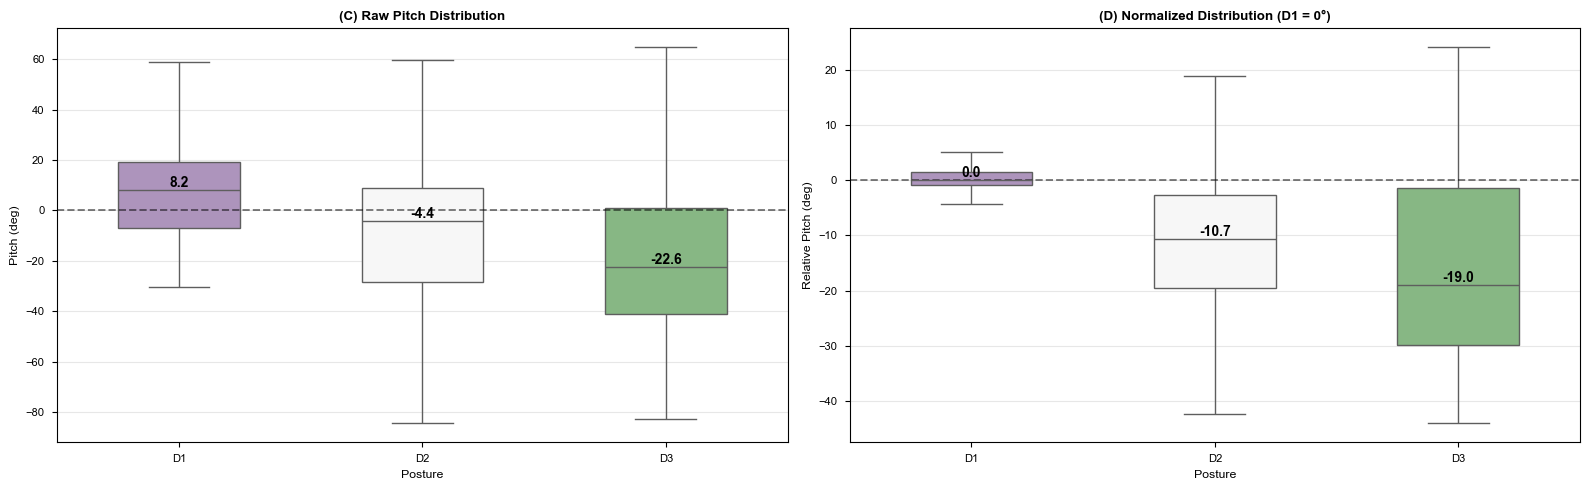

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_posture_distribution_raw_vs_norm(df_norm):
    posture_order = ["d1", "d2", "d3"]
    posture_labels = ["D1", "D2", "D3"]
    posture_colors = {
        "d1": "#af8dc3",  # purple
        "d2": "#f7f7f7",  # light gray
        "d3": "#7fbf7b",  # green
    }

    plt.style.use("seaborn-v0_8-paper")
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # -------- long-form data for raw and normalized --------
    raw_long = pd.concat([
        pd.DataFrame({"post": r["post"], "val": r["sig"]})
        for _, r in df_norm.iterrows()
    ])
    norm_long = pd.concat([
        pd.DataFrame({"post": r["post"], "val": r["norm_sig"]})
        for _, r in df_norm.iterrows()
    ])

    raw_long["post"] = pd.Categorical(raw_long["post"], posture_order, ordered=True)
    norm_long["post"] = pd.Categorical(norm_long["post"], posture_order, ordered=True)

    # -------- (C) Raw pitch distribution --------
    ax_raw = axes[0]
    sns.boxplot(
        data=raw_long,
        x="post",
        y="val",
        order=posture_order,
        palette=posture_colors,
        showfliers=False,
        width=0.5,
        ax=ax_raw,
    )
    ax_raw.axhline(0, linestyle="--", color="black", alpha=0.5)
    ax_raw.set_title("(C) Raw Pitch Distribution", fontweight="bold")
    ax_raw.set_xlabel("Posture")
    ax_raw.set_ylabel("Pitch (deg)")
    ax_raw.set_xticklabels(posture_labels)
    ax_raw.grid(axis="y", alpha=0.3)

    # annotate medians
    for i, post in enumerate(posture_order):
        med = raw_long.loc[raw_long["post"] == post, "val"].median()
        ax_raw.text(i, med, f"{med:.1f}", ha="center", va="bottom", fontweight="bold")

    # -------- (D) Normalized distribution --------
    ax_norm = axes[1]
    sns.boxplot(
        data=norm_long,
        x="post",
        y="val",
        order=posture_order,
        palette=posture_colors,
        showfliers=False,
        width=0.5,
        ax=ax_norm,
    )
    ax_norm.axhline(0, linestyle="--", color="black", alpha=0.5)
    ax_norm.set_title("(D) Normalized Distribution (D1 = 0°)", fontweight="bold")
    ax_norm.set_xlabel("Posture")
    ax_norm.set_ylabel("Relative Pitch (deg)")
    ax_norm.set_xticklabels(posture_labels)
    ax_norm.grid(axis="y", alpha=0.3)

    for i, post in enumerate(posture_order):
        med = norm_long.loc[norm_long["post"] == post, "val"].median()
        ax_norm.text(i, med, f"{med:.1f}", ha="center", va="bottom", fontweight="bold")

    plt.tight_layout()
    plt.show()

# Call after df_norm["norm_sig"] is defined
plot_posture_distribution_raw_vs_norm(df_norm)


In [35]:
def plot_posture_academic_annotated(df_norm, save_dir=None):
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'pdf.fonttype': 42
    })

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    posture_order = ["d1", "d2", "d3"]
    posture_labels = ["Neutral (D1)", "Intermed. (D2)", "Maximal (D3)"]
    palette = ["#deebf7", "#9ecae1", "#3182bd"]

    for i, (col, title, ylabel) in enumerate([
        ("sig", "(A) Raw Pitch (Inter-Subject Variance)", "Pitch (°)"),
        ("norm_sig", "(B) Normalized Flexion (Baseline Corrected)", "Relative Pitch (°)")
    ]):
        ax = axes[i]

        long_df = pd.concat([
            pd.DataFrame({"post": r["post"], "val": r[col]})
            for _, r in df_norm.iterrows()
        ], ignore_index=True)
        long_df["post"] = pd.Categorical(long_df["post"], posture_order, ordered=True)

        sns.boxplot(
            data=long_df, x="post", y="val", order=posture_order,
            palette=palette, showfliers=False, width=0.5,
            linewidth=1.5, ax=ax
        )

        ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.4, zorder=0)

        ax.set_title(title, fontweight='bold', fontsize=12, pad=25)
        ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
        ax.set_xlabel("Posture Condition", fontsize=11, fontweight='bold')
        ax.set_xticklabels(posture_labels, fontweight='bold')

        y_range = long_df["val"].max() - long_df["val"].min()

        for j, post in enumerate(posture_order):
            med = long_df.loc[long_df["post"] == post, "val"].median()
            q3  = long_df.loc[long_df["post"] == post, "val"].quantile(0.75)
            ax.text(j, q3 + (y_range * 0.05), f"{med:.1f}°",
                    ha='center', va='bottom', fontweight='bold',
                    color='#333333', fontsize=10)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(False)

    fig.tight_layout()

    # SAVE BEFORE SHOW
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(os.path.join(save_dir, "posture_analysis.pdf"), dpi=300, bbox_inches="tight")
        fig.savefig(os.path.join(save_dir, "posture_analysis.png"), dpi=300, bbox_inches="tight")

    plt.show()
    return fig


/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/1186633937.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/1186633937.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(posture_labels, fontweight='bold')
/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/1186633937.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/1186633937.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. aft

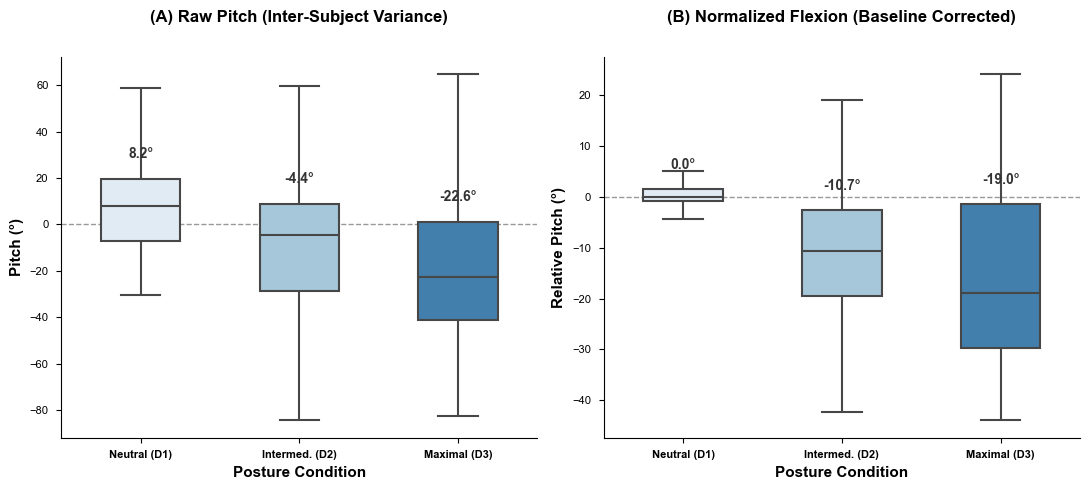

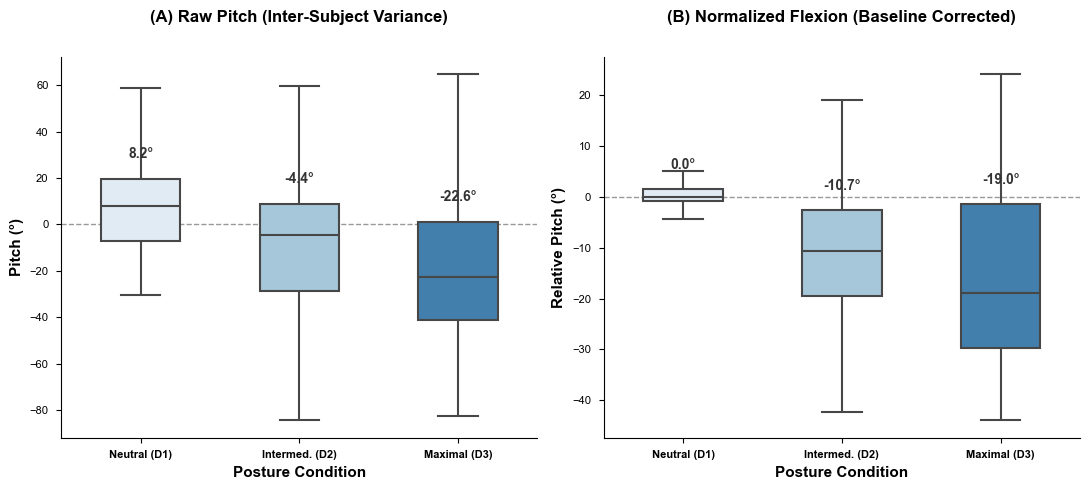

In [36]:
plot_dir = "/Users/sgomasta/Desktop/Tech Neck Coding/Plots"
plot_posture_academic_annotated(df_norm, save_dir=plot_dir)


/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/1495230517.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/1495230517.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Neutral (D1)", "Intermediate (D2)", "Maximal (D3)"])
/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/1495230517.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/1495230517.py:53: UserWarning: set_ticklabels() should only be used with a fixed numbe

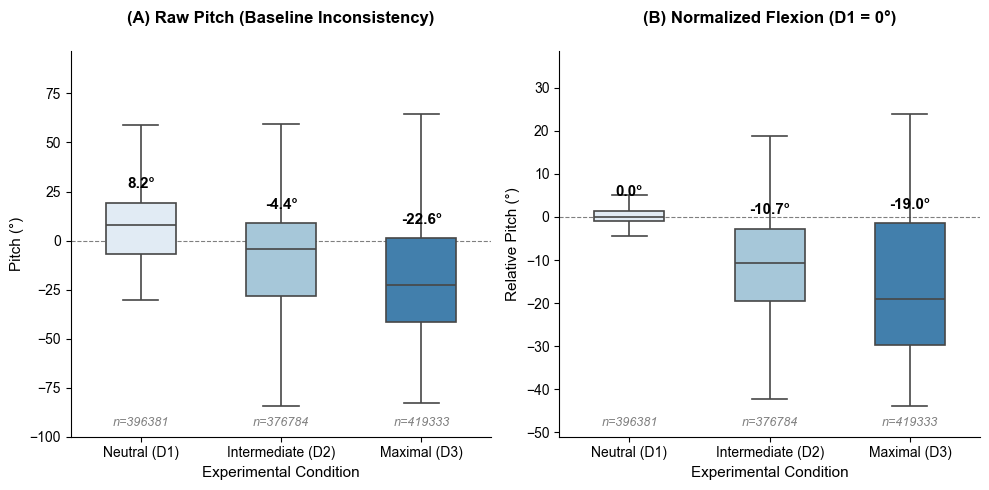


SUMMARY STATISTICS

Raw Pitch:
----------------------------------------------------------------------
D1: median=8.17°, IQR=[-6.99, 19.39], mean±SD=3.47±35.43, n=396381
D2: median=-4.36°, IQR=[-28.48, 8.81], mean±SD=-9.74±34.19, n=376784
D3: median=-22.60°, IQR=[-41.32, 1.12], mean±SD=-17.95±34.40, n=419333

Normalized Pitch:
----------------------------------------------------------------------
D1: median=0.00°, IQR=[-0.87, 1.48], mean±SD=0.49±3.19, n=396381
D2: median=-10.69°, IQR=[-19.56, -2.69], mean±SD=-11.64±11.68, n=376784
D3: median=-18.97°, IQR=[-29.74, -1.43], mean±SD=-15.86±16.43, n=419333


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

def add_significance_bracket(ax, x1, x2, y, h, text):
    """Draws a bracket with a significance label (e.g., ***)"""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c='black')
    ax.text((x1+x2)*.5, y+h, text, ha='center', va='bottom', color='black', fontsize=12)

def plot_posture_academic(df_norm, save_path=None, dpi=300):
    # Setup styles for ACM/IEEE publication
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'pdf.fonttype': 42,  # Ensures text is editable in Illustrator
        'ps.fonttype': 42
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)
    
    # Palette representing severity: Neutral -> Intermediate -> Deep Flexion
    posture_order = ["d1", "d2", "d3"]
    # Sequential palette: Light Blue -> Medium Blue -> Dark Navy
    academic_palette = ["#deebf7", "#9ecae1", "#3182bd"]
    
    for i, (panel_title, col_name, y_label) in enumerate([
        ("(A) Raw Pitch (Baseline Inconsistency)", "sig", "Pitch (°)"),
        ("(B) Normalized Flexion (D1 = 0°)", "norm_sig", "Relative Pitch (°)")
    ]):
        ax = axes[i]
        
        # Melt data for plotting
        long_df = pd.concat([
            pd.DataFrame({"post": r["post"], "val": r[col_name]})
            for _, r in df_norm.iterrows()
        ], ignore_index=True)
        long_df["post"] = pd.Categorical(long_df["post"], posture_order, ordered=True)
        
        # Plot with capped whiskers and thinner boxes
        sns.boxplot(
            data=long_df, x="post", y="val", order=posture_order,
            palette=academic_palette, showfliers=False, width=0.5,
            linewidth=1.2, ax=ax, whis=1.5
        )
        
        # Labels and Styling
        ax.set_title(panel_title, fontweight='bold', fontsize=12, pad=20)
        ax.set_ylabel(y_label, fontsize=11)
        ax.set_xlabel("Experimental Condition", fontsize=11)
        ax.set_xticklabels(["Neutral (D1)", "Intermediate (D2)", "Maximal (D3)"])
        
        # Zero line
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5, zorder=0)
        
        # Clean Spines
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        
        # Extend y-axis to make room for annotations
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        ax.set_ylim(y_min - y_range * 0.05, y_max + y_range * 0.15)
        
        # Annotate median values
        for j, post in enumerate(posture_order):
            vals = long_df.loc[long_df["post"] == post, "val"]
            median = vals.median()
            q3 = vals.quantile(0.75)
            
            # Get updated y-range after axis extension
            y_range_new = ax.get_ylim()[1] - ax.get_ylim()[0]
            
            # Position annotation above Q3
            ax.text(j, q3 + y_range_new * 0.03, f"{median:.1f}°", 
                   ha="center", va="bottom", fontweight="bold", 
                   fontsize=11, color='black')
        
        # Add sample size annotation
        for j, post in enumerate(posture_order):
            n = len(long_df.loc[long_df["post"] == post])
            ax.text(j, ax.get_ylim()[0] + y_range_new * 0.02, f'n={n}', 
                   ha='center', va='bottom', fontsize=9, style='italic', color='gray')
    
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        print(f"Figure saved: {save_path}")
    
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*70)
    print("SUMMARY STATISTICS")
    print("="*70)
    
    for col_name, title in [("sig", "Raw Pitch"), ("norm_sig", "Normalized Pitch")]:
        print(f"\n{title}:")
        print("-" * 70)
        
        long_df = pd.concat([
            pd.DataFrame({"post": r["post"], "val": r[col_name]})
            for _, r in df_norm.iterrows()
        ], ignore_index=True)
        
        for post in ["d1", "d2", "d3"]:
            vals = long_df.loc[long_df["post"] == post, "val"]
            print(f"{post.upper()}: median={vals.median():.2f}°, "
                  f"IQR=[{vals.quantile(0.25):.2f}, {vals.quantile(0.75):.2f}], "
                  f"mean±SD={vals.mean():.2f}±{vals.std():.2f}, "
                  f"n={len(vals)}")

# Usage:
plot_posture_academic(df_norm)
# plot_posture_academic(df_norm, save_path='figure_posture.pdf')
# plot_posture_academic(df_norm, save_path='figure_posture.png', dpi=300)

/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/1098478406.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/1098478406.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Neutral", "Mild Forward Flexion", "Deep Forward Flexion"])
/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/1098478406.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/1098478406.py:56: UserWarning: set_ticklabels() should only be used with a fixed

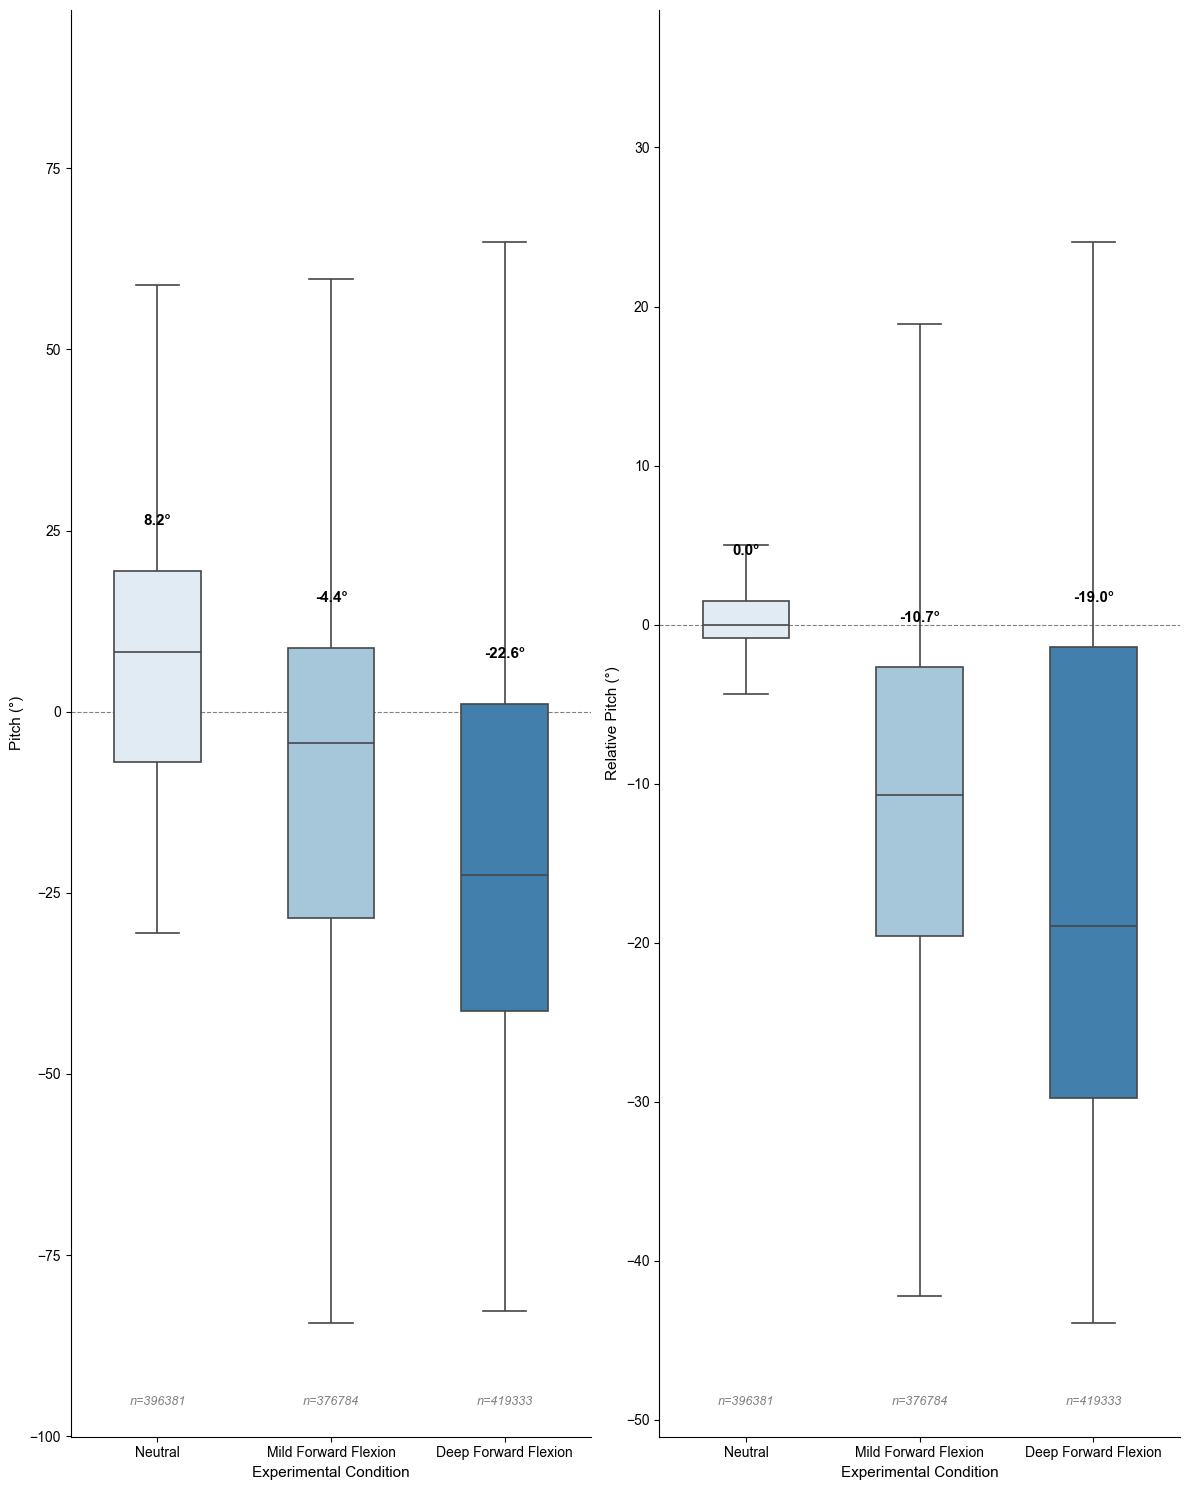


SUMMARY STATISTICS

Raw Pitch:
----------------------------------------------------------------------
D1: median=8.17°, IQR=[-6.99, 19.39], mean±SD=3.47±35.43, n=396381
D2: median=-4.36°, IQR=[-28.48, 8.81], mean±SD=-9.74±34.19, n=376784
D3: median=-22.60°, IQR=[-41.32, 1.12], mean±SD=-17.95±34.40, n=419333

Normalized Pitch:
----------------------------------------------------------------------
D1: median=0.00°, IQR=[-0.87, 1.48], mean±SD=0.49±3.19, n=396381
D2: median=-10.69°, IQR=[-19.56, -2.69], mean±SD=-11.64±11.68, n=376784
D3: median=-18.97°, IQR=[-29.74, -1.43], mean±SD=-15.86±16.43, n=419333


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

def add_significance_bracket(ax, x1, x2, y, h, text):
    """Draws a bracket with a significance label (e.g., ***)"""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c='black')
    ax.text((x1+x2)*.5, y+h, text, ha='center', va='bottom', color='black', fontsize=12)

def plot_posture_academic(df_norm, save_path=None, dpi=300):
    # Setup styles for ACM/IEEE publication
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'pdf.fonttype': 42,  # Ensures text is editable in Illustrator
        'ps.fonttype': 42
    })
    
    # Figure size updated to (12, 15)
    fig, axes = plt.subplots(1, 2, figsize=(12, 15), sharex=True)
    
    # Palette representing severity: Neutral -> Mild Forward Flexion -> Deep Forward Flexion
    posture_order = ["d1", "d2", "d3"]
    academic_palette = ["#deebf7", "#9ecae1", "#3182bd"]
    
    for i, (panel_title, col_name, y_label) in enumerate([
        ("(A) Raw Pitch (Baseline Inconsistency)", "sig", "Pitch (°)"),
        ("(B) Normalized Flexion (D1 = 0°)", "norm_sig", "Relative Pitch (°)")
    ]):
        ax = axes[i]
        
        # Melt data for plotting
        long_df = pd.concat([
            pd.DataFrame({"post": r["post"], "val": r[col_name]})
            for _, r in df_norm.iterrows()
        ], ignore_index=True)
        long_df["post"] = pd.Categorical(long_df["post"], posture_order, ordered=True)
        
        # Plot with capped whiskers and thinner boxes
        sns.boxplot(
            data=long_df, x="post", y="val", order=posture_order,
            palette=academic_palette, showfliers=False, width=0.5,
            linewidth=1.2, ax=ax, whis=1.5
        )
        
        # Labels and Styling
        # Removed figure headers (panel titles) as requested
        # ax.set_title(panel_title, fontweight='bold', fontsize=12, pad=20)
        ax.set_ylabel(y_label, fontsize=11)
        ax.set_xlabel("Experimental Condition", fontsize=11)
        
        # Updated xtick labels as requested
        ax.set_xticklabels(["Neutral", "Mild Forward Flexion", "Deep Forward Flexion"])
        
        # Zero line
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5, zorder=0)
        
        # Clean Spines
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        
        # Extend y-axis to make room for annotations
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        ax.set_ylim(y_min - y_range * 0.05, y_max + y_range * 0.15)
        
        # Get updated y-range after axis extension (define once per axis)
        y_range_new = ax.get_ylim()[1] - ax.get_ylim()[0]
        
        # Annotate median values
        for j, post in enumerate(posture_order):
            vals = long_df.loc[long_df["post"] == post, "val"]
            median = vals.median()
            q3 = vals.quantile(0.75)
            
            # Position annotation above Q3
            ax.text(
                j, q3 + y_range_new * 0.03, f"{median:.1f}°",
                ha="center", va="bottom", fontweight="bold",
                fontsize=11, color='black'
            )
        
        # Add sample size annotation
        for j, post in enumerate(posture_order):
            n = len(long_df.loc[long_df["post"] == post])
            ax.text(
                j, ax.get_ylim()[0] + y_range_new * 0.02, f'n={n}',
                ha='center', va='bottom', fontsize=9, style='italic', color='gray'
            )
    
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
        print(f"Figure saved: {save_path}")
    
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*70)
    print("SUMMARY STATISTICS")
    print("="*70)
    
    for col_name, title in [("sig", "Raw Pitch"), ("norm_sig", "Normalized Pitch")]:
        print(f"\n{title}:")
        print("-" * 70)
        
        long_df = pd.concat([
            pd.DataFrame({"post": r["post"], "val": r[col_name]})
            for _, r in df_norm.iterrows()
        ], ignore_index=True)
        
        for post in ["d1", "d2", "d3"]:
            vals = long_df.loc[long_df["post"] == post, "val"]
            print(
                f"{post.upper()}: median={vals.median():.2f}°, "
                f"IQR=[{vals.quantile(0.25):.2f}, {vals.quantile(0.75):.2f}], "
                f"mean±SD={vals.mean():.2f}±{vals.std():.2f}, "
                f"n={len(vals)}"
            )

# Usage:
plot_posture_academic(df_norm)
# plot_posture_academic(df_norm, save_path='figure_posture.pdf')
# plot_posture_academic(df_norm, save_path='figure_posture.png', dpi=300)


In [41]:
from pathlib import Path
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler


# ================= CONFIG =================
IMU_FS = 50
TRIM_SAMPLES = 10 * IMU_FS  # first 10 s
WINDOW_SEC = 5
OVERLAP = 0.5
WIN_LEN = int(WINDOW_SEC * IMU_FS)   # 250 samples
STEP = int(WIN_LEN * (1 - OVERLAP))  # 125 samples

DERIVED_ROOT = Path("")
imu_files = list(DERIVED_ROOT.rglob("imu/**/*.csv"))
print("IMU files found:", len(imu_files))

# ================= HELPERS =================
def get_metadata(path_str):
    parts = path_str.split("/")
    participant = parts[6] if len(parts) > 6 else "UNKNOWN"
    task = parts[8] if len(parts) > 8 else "UNK_TASK"
    filename = os.path.basename(path_str).lower()
    posture_match = re.search(r"d[1-3]", filename)
    posture = posture_match.group(0) if posture_match else None
    return participant, task, posture

def hjorth_params(x):
    """Hjorth activity, mobility, complexity for 1D signal x."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 5:
        return {
            "hjorth_activity": 0.0,
            "hjorth_mobility": 0.0,
            "hjorth_complexity": 0.0,
        }
    dx = np.diff(x)
    ddx = np.diff(dx)
    var_x = np.var(x)
    var_dx = np.var(dx)
    var_ddx = np.var(ddx)
    activity = var_x
    mobility = np.sqrt(var_dx / (var_x + 1e-12))
    complexity = np.sqrt(
        (var_ddx / (var_dx + 1e-12)) /
        (var_dx / (var_x + 1e-12) + 1e-12)
    )
    return {
        "hjorth_activity": float(activity),
        "hjorth_mobility": float(mobility),
        "hjorth_complexity": float(complexity),
    }

def spectral_entropy(psd):
    psd = np.asarray(psd, dtype=float)
    psd = psd[np.isfinite(psd)]
    if psd.size == 0:
        return 0.0
    p = psd / (psd.sum() + 1e-12)
    return float(-np.sum(p * np.log2(p + 1e-12)))

# ================= LOAD + BUILD df_norm =================
records = []
for path in imu_files:
    path_str = str(path)
    p, task, post = get_metadata(path_str)
    if post not in {"d1", "d2", "d3"}:
        continue

    df = pd.read_csv(path_str)
    if "Pitch" not in df.columns:
        print(f"Skipping {path_str}: 'Pitch' column not found")
        continue

    pitch = df["Pitch"].values.astype(float)
    pitch = pitch[TRIM_SAMPLES:]  # discard first 10 s

    records.append({
        "p": p,
        "task": task,
        "post": post,
        "sig": pitch,
        "path": path_str,
    })

df_norm = pd.DataFrame(records)
print("df_norm columns:", df_norm.columns)
print("df_norm head:\n", df_norm.head())

# ================= BASELINE CENTERING (NO SIGN) =================
baselines = (
    df_norm[df_norm["post"] == "d1"]
    .groupby("p")["sig"]
    .apply(lambda s: np.median(np.concatenate(s.values)))
    .to_dict()
)
print("\nParticipant baselines (P_base):")
for p, b in baselines.items():
    print(f"  {p}: {b:.2f} deg")

df_norm["P_base"] = df_norm["p"].map(baselines)

df_norm["norm_sig"] = df_norm.apply(
    lambda r: r["sig"] - r["P_base"] if r["P_base"] is not None else r["sig"],
    axis=1
)

print(
    "\nBaseline-centered df_norm head:\n",
    df_norm[["p", "post", "P_base"]].head()
)

# ================= FEATURE EXTRACTION (ENHANCED IMU FEATURES) =================
features = []
for _, row in df_norm.iterrows():
    sig = row["norm_sig"]  # baseline-centered flex
    if len(sig) < WIN_LEN:
        continue

    for start in range(0, len(sig) - WIN_LEN + 1, STEP):
        w = sig[start:start + WIN_LEN]

        # basic stats
        mean_w = float(np.mean(w))
        median_w = float(np.median(w))
        std_w = float(np.std(w))
        rms_w = float(np.sqrt(np.mean(w**2)))
        range_w = float(np.ptp(w))
        iqr_w = float(np.percentile(w, 75) - np.percentile(w, 25))
        skew_w = float(skew(w)) if len(w) > 10 else 0.0
        kurt_w = float(kurtosis(w)) if len(w) > 10 else 0.0

        # velocity and MAV (derivative)
        vel = np.diff(w) * IMU_FS
        mav_w = float(np.mean(np.abs(vel))) if len(vel) > 0 else 0.0

        # acceleration from velocity
        if len(vel) > 1:
            acc = np.diff(vel) * IMU_FS
        else:
            acc = np.array([])
        acc_mean = float(np.mean(np.abs(acc))) if len(acc) > 0 else 0.0
        acc_std = float(np.std(acc)) if len(acc) > 0 else 0.0
        acc_max = float(np.max(np.abs(acc))) if len(acc) > 0 else 0.0

        # zero-crossing rate around mean
        if len(w) > 1:
            zc = float(
                np.sum(np.diff(np.sign(w - mean_w)) != 0) / len(w)
            )
        else:
            zc = 0.0

        # line length
        ll = float(np.sum(np.abs(np.diff(w)))) if len(w) > 1 else 0.0

        # Hjorth parameters
        hj = hjorth_params(w)
        hj_act = hj["hjorth_activity"]
        hj_mob = hj["hjorth_mobility"]
        hj_comp = hj["hjorth_complexity"]

        # simple spectral features over the 5 s window
        n = len(w)
        if n >= 64:
            w_d = w - mean_w
            yf = np.fft.fft(w_d)
            xf = np.fft.fftfreq(n, 1/IMU_FS)[:n//2]
            power = np.abs(yf[:n//2])**2

            if power.size > 0 and np.max(power) > 0:
                dom_idx = int(np.argmax(power))
                dom_freq = float(xf[dom_idx])
            else:
                dom_freq = 0.0

            spec_ent = spectral_entropy(power)

            low_mask = xf < 1.0
            high_mask = xf >= 1.0
            low_power = float(np.sum(power[low_mask])) if np.any(low_mask) else 0.0
            high_power = float(np.sum(power[high_mask])) if np.any(high_mask) else 0.0
            total_power = low_power + high_power + 1e-12

            low_freq_ratio = low_power / total_power
            high_freq_ratio = high_power / total_power
        else:
            dom_freq = 0.0
            spec_ent = 0.0
            low_power = 0.0
            high_power = 0.0
            low_freq_ratio = 0.0
            high_freq_ratio = 0.0

        features.append({
            "participant": row["p"],
            "label": row["post"],

            # original-style stats
            "mean": mean_w,
            "median": median_w,
            "std": std_w,
            "rms": rms_w,
            "range": range_w,
            "skew": skew_w,
            "kurt": kurt_w,
            "iqr": iqr_w,
            "mav": mav_w,
            "zcr": zc,

            # enhanced features
            "ll": ll,
            "vel_mean": float(np.mean(np.abs(vel))) if len(vel) > 0 else 0.0,
            "vel_std": float(np.std(vel)) if len(vel) > 0 else 0.0,
            "vel_max": float(np.max(np.abs(vel))) if len(vel) > 0 else 0.0,
            "acc_mean": acc_mean,
            "acc_std": acc_std,
            "acc_max": acc_max,
            "hj_activity": hj_act,
            "hj_mobility": hj_mob,
            "hj_complexity": hj_comp,
            "dom_freq": dom_freq,
            "spec_entropy": spec_ent,
            "low_freq_power": low_power,
            "high_freq_power": high_power,
            "low_freq_ratio": low_freq_ratio,
            "high_freq_ratio": high_freq_ratio,
        })

df_feat = pd.DataFrame(features).dropna()
print(f"\nExtracted {len(df_feat)} windows with {df_feat.shape[1]-2} IMU features each.")
print("df_feat columns:", df_feat.columns)

# ================= MODELS =================
RF_CFG = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

def make_models(num_classes):
    models = {
        "RF": RandomForestClassifier(**RF_CFG),
        "SVM": SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=False,
            class_weight="balanced",
            random_state=42,
        ),
        "GB": GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
        ),
    }
    if HAS_XGB:
        obj = "binary:logistic" if num_classes == 2 else "multi:softmax"
        models["XGB"] = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective=obj,
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
        )
    return models

# ================= 80/20 PER-SUBJECT =================
def eval_8020_per_subject(df_feat, y_array, labels, title):
    X_cols = [c for c in df_feat.columns if c not in ["participant", "label"]]
    models = make_models(num_classes=len(labels))
    results_cm = {}

    for name, model in models.items():
        all_true, all_pred = [], []

        for pid in df_feat["participant"].unique():
            sub = df_feat[df_feat["participant"] == pid]
            if len(sub) < 5:
                continue

            X_sub = sub[X_cols].reset_index(drop=True)
            y_sub = y_array[sub.index].reset_index(drop=True)

            n = len(X_sub)
            split_idx = int(0.8 * n)
            X_tr, X_te = X_sub.iloc[:split_idx], X_sub.iloc[split_idx:]
            y_tr, y_te = y_sub.iloc[:split_idx], y_sub.iloc[split_idx:]

            if len(np.unique(y_tr)) < len(labels):
                continue

            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_te_s = scaler.transform(X_te)

            model.fit(X_tr_s, y_tr)
            y_hat = model.predict(X_te_s)

            all_true.append(y_te.values)
            all_pred.append(y_hat)

        if not all_true:
            print(f"[{title} – {name} 80/20] Not enough data per participant.")
            continue

        all_true = np.concatenate(all_true)
        all_pred = np.concatenate(all_pred)

        acc = accuracy_score(all_true, all_pred)
        print(f"[{title} – {name} 80/20] Accuracy: {acc:.3f}")
        print(classification_report(all_true, all_pred, target_names=labels))

        cm = confusion_matrix(all_true, all_pred)
        results_cm[name] = cm

    return results_cm

# ================= LOSO =================
def eval_loso(df_feat, y_array, labels, title):
    X_cols = [c for c in df_feat.columns if c not in ["participant", "label"]]
    X = df_feat[X_cols].reset_index(drop=True)
    y = y_array.reset_index(drop=True)
    groups = df_feat["participant"].reset_index(drop=True)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    models = make_models(num_classes=len(labels))
    results_cm = {}

    for name, model in models.items():
        y_true_all, y_pred_all = [], []
        logo = LeaveOneGroupOut()

        for train_idx, test_idx in logo.split(X_scaled, y, groups):
            X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

            if len(np.unique(y_tr)) < len(labels):
                continue

            model.fit(X_tr, y_tr)
            y_hat = model.predict(X_te)

            y_true_all.append(y_te.values)
            y_pred_all.append(y_hat)

        if not y_true_all:
            print(f"[{title} – {name} LOSO] Not enough class diversity in folds.")
            continue

        y_true_all = np.concatenate(y_true_all)
        y_pred_all = np.concatenate(y_pred_all)

        acc = accuracy_score(y_true_all, y_pred_all)
        print(f"[{title} – {name} LOSO] Accuracy: {acc:.3f}")
        print(classification_report(y_true_all, y_pred_all, target_names=labels))

        cm = confusion_matrix(y_true_all, y_pred_all)
        results_cm[name] = cm

    return results_cm

# ================= PLOTTING =================
def plot_all_models(cm_8020_dict, cm_loso_dict, labels, title):
    model_names = ["RF", "SVM", "XGB", "GB"] if HAS_XGB else ["RF", "SVM", "GB"]
    fig, axes = plt.subplots(2, len(model_names), figsize=(4 * len(model_names), 8))

    for j, name in enumerate(model_names):
        # 80/20
        ax = axes[0, j]
        if name in cm_8020_dict:
            sns.heatmap(
                cm_8020_dict[name],
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=labels,
                yticklabels=labels,
                ax=ax,
            )
            ax.set_title(f"{name} – 80/20")
            ax.set_xlabel("Predicted")
            ax.set_ylabel("True")
        else:
            ax.axis("off")

        # LOSO
        ax = axes[1, j]
        if name in cm_loso_dict:
            sns.heatmap(
                cm_loso_dict[name],
                annot=True,
                fmt="d",
                cmap="Greens",
                xticklabels=labels,
                yticklabels=labels,
                ax=ax,
            )
            ax.set_title(f"{name} – LOSO")
            ax.set_xlabel("Predicted")
            ax.set_ylabel("True")
        else:
            ax.axis("off")

    fig.suptitle(title, fontweight="bold")
    plt.tight_layout()
    plt.show()

# ================= RUN TASKS =================
# Multi-class D1/D2/D3
y_multi = df_feat["label"].map({"d1": 0, "d2": 1, "d3": 2})
labels_multi = ["D1", "D2", "D3"]

print("\n===== IMU MULTI-CLASS (D1/D2/D3) =====")
cm_8020_multi = eval_8020_per_subject(df_feat, y_multi, labels_multi, "IMU Multi-Class")
cm_loso_multi = eval_loso(df_feat, y_multi, labels_multi, "IMU Multi-Class")
plot_all_models(cm_8020_multi, cm_loso_multi, labels_multi, "IMU Multi-Class Posture")

# Binary D1 vs (D2+D3)
y_bin = df_feat["label"].map({"d1": 0, "d2": 1, "d3": 1})
labels_bin = ["D1 (Good)", "Slouch (D2+D3)"]

print("\n===== IMU BINARY (D1 vs Slouch) =====")
cm_8020_bin = eval_8020_per_subject(df_feat, y_bin, labels_bin, "IMU Binary")
cm_loso_bin = eval_loso(df_feat, y_bin, labels_bin, "IMU Binary")
plot_all_models(cm_8020_bin, cm_loso_bin, labels_bin, "IMU Binary Posture")


IMU files found: 152
df_norm columns: Index(['p', 'task', 'post', 'sig', 'path'], dtype='object')
df_norm head:
        p       task post                                                sig  \
0  Abhay  numerical   d3  [23.44426915592, 23.44426915592, 23.5281985204...   
1  Abhay  numerical   d2  [20.7025765816, 20.75852949128, 20.75852949128...   
2  Abhay  numerical   d1  [52.455852825, 52.51180573468, 52.567758644360...   
3  Abhay       rest   d1  [48.28736105384, 48.28736105384, 48.2873610538...   
4  Abhay       rest   d2  [22.381163872, 22.381163872, 22.381163872, 22....   

                                                path  
0  /Users/sgomasta/Desktop/Tech Neck Coding/deriv...  
1  /Users/sgomasta/Desktop/Tech Neck Coding/deriv...  
2  /Users/sgomasta/Desktop/Tech Neck Coding/deriv...  
3  /Users/sgomasta/Desktop/Tech Neck Coding/deriv...  
4  /Users/sgomasta/Desktop/Tech Neck Coding/deriv...  

Participant baselines (P_base):
  AZIZ: -61.74 deg
  Abhay: 49.97 deg
  Ankur: -2

/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/1113245943.py:149: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew_w = float(skew(w)) if len(w) > 10 else 0.0
/var/folders/2m/lbyj3ty17pgdhprp09321csm0000gq/T/ipykernel_93377/1113245943.py:150: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt_w = float(kurtosis(w)) if len(w) > 10 else 0.0



Extracted 9425 windows with 26 IMU features each.
df_feat columns: Index(['participant', 'label', 'mean', 'median', 'std', 'rms', 'range', 'skew',
       'kurt', 'iqr', 'mav', 'zcr', 'll', 'vel_mean', 'vel_std', 'vel_max',
       'acc_mean', 'acc_std', 'acc_max', 'hj_activity', 'hj_mobility',
       'hj_complexity', 'dom_freq', 'spec_entropy', 'low_freq_power',
       'high_freq_power', 'low_freq_ratio', 'high_freq_ratio'],
      dtype='object')

===== IMU MULTI-CLASS (D1/D2/D3) =====
[IMU Multi-Class – RF 80/20] Accuracy: 0.738
              precision    recall  f1-score   support

          D1       0.84      0.80      0.82       721
          D2       0.61      0.65      0.63       524
          D3       0.74      0.74      0.74       650

    accuracy                           0.74      1895
   macro avg       0.73      0.73      0.73      1895
weighted avg       0.74      0.74      0.74      1895

[IMU Multi-Class – SVM 80/20] Accuracy: 0.718
              precision    recall  f1

KeyboardInterrupt: 

<H1>IMu featurewise ablation Study </h1>

In [123]:
# ================= FEATURE GROUP ABLATION STUDY =================
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd


from sklearn.metrics import precision_recall_fscore_support

# ── Define feature groups ──────────────────────────────────────────────────
FEATURE_GROUPS = {
    "Time-Domain": [
        "mean", "median", "std", "rms", "range", "skew", "kurt", "iqr", "mav", "zcr", "ll"
    ],
    "Derivative": [
        "vel_mean", "vel_std", "vel_max", "acc_mean", "acc_std", "acc_max"
    ],
    "Hjorth": [
        "hj_activity", "hj_mobility", "hj_complexity"
    ],
    "Frequency-Domain": [
        "dom_freq", "spec_entropy", "low_freq_power", "high_freq_power",
        "low_freq_ratio", "high_freq_ratio"
    ],
}
FEATURE_GROUPS["All Features"] = sum(FEATURE_GROUPS.values(), [])

RF_ABL = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

# ── Helper: metrics + top-5 importance ────────────────────────────────────
def summarise(y_true, y_pred, feature_cols, importances):
    acc = accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    top5_idx = np.argsort(importances)[::-1][:5]
    top5 = [(feature_cols[i], round(importances[i], 4)) for i in top5_idx]
    return acc, p, r, f, top5

# ── 80/20 per-subject ablation ─────────────────────────────────────────────
def ablation_8020(df_feat, y_array, labels, task_name):
    print(f"\n{'='*60}")
    print(f"  ABLATION — 80/20  |  {task_name}")
    print(f"{'='*60}")

    rows = []
    for grp_name, cols in FEATURE_GROUPS.items():
        cols = [c for c in cols if c in df_feat.columns]  # safety check
        all_true, all_pred = [], []
        all_imp = np.zeros(len(cols))
        n_folds = 0

        for pid in df_feat["participant"].unique():
            sub = df_feat[df_feat["participant"] == pid]
            if len(sub) < 5:
                continue
            X_sub = sub[cols].reset_index(drop=True)
            y_sub = y_array[sub.index].reset_index(drop=True)

            split = int(0.8 * len(X_sub))
            X_tr, X_te = X_sub.iloc[:split], X_sub.iloc[split:]
            y_tr, y_te = y_sub.iloc[:split], y_sub.iloc[split:]

            if len(np.unique(y_tr)) < len(labels):
                continue

            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_te_s = scaler.transform(X_te)

            clf = RandomForestClassifier(
                n_estimators=300, max_depth=10, min_samples_leaf=5,
                class_weight="balanced", random_state=42, n_jobs=-1,
            )
            clf.fit(X_tr_s, y_tr)
            all_true.append(y_te.values)
            all_pred.append(clf.predict(X_te_s))
            all_imp += clf.feature_importances_
            n_folds += 1

        if not all_true:
            continue

        all_imp /= max(n_folds, 1)
        acc, p, r, f, top5 = summarise(
            np.concatenate(all_true),
            np.concatenate(all_pred),
            cols, all_imp
        )

        print(f"\n  Group : {grp_name}")
        print(f"  Acc={acc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")
        print(f"  Top-5 RF importance: {top5}")
        rows.append({
            "Group": grp_name, "Eval": "80/20",
            "Acc": round(acc,3), "Precision": round(p,3),
            "Recall": round(r,3), "F1": round(f,3),
            "Top5": top5,
        })
    return rows

# ── LOSO ablation ──────────────────────────────────────────────────────────
def ablation_loso(df_feat, y_array, labels, task_name):
    print(f"\n{'='*60}")
    print(f"  ABLATION — LOSO   |  {task_name}")
    print(f"{'='*60}")

    logo = LeaveOneGroupOut()
    groups = df_feat["participant"].reset_index(drop=True)
    rows = []

    for grp_name, cols in FEATURE_GROUPS.items():
        cols = [c for c in cols if c in df_feat.columns]
        X = df_feat[cols].reset_index(drop=True)
        y = y_array.reset_index(drop=True)

        scaler = StandardScaler()
        X_s = scaler.fit_transform(X)

        all_true, all_pred = [], []
        all_imp = np.zeros(len(cols))
        n_folds = 0

        for tr_idx, te_idx in logo.split(X_s, y, groups):
            y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
            if len(np.unique(y_tr)) < len(labels):
                continue

            clf = RandomForestClassifier(
                n_estimators=300, max_depth=10, min_samples_leaf=5,
                class_weight="balanced", random_state=42, n_jobs=-1,
            )
            clf.fit(X_s[tr_idx], y_tr)
            all_true.append(y_te.values)
            all_pred.append(clf.predict(X_s[te_idx]))
            all_imp += clf.feature_importances_
            n_folds += 1

        if not all_true:
            continue

        all_imp /= max(n_folds, 1)
        acc, p, r, f, top5 = summarise(
            np.concatenate(all_true),
            np.concatenate(all_pred),
            cols, all_imp
        )

        print(f"\n  Group : {grp_name}")
        print(f"  Acc={acc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")
        print(f"  Top-5 RF importance: {top5}")
        rows.append({
            "Group": grp_name, "Eval": "LOSO",
            "Acc": round(acc,3), "Precision": round(p,3),
            "Recall": round(r,3), "F1": round(f,3),
            "Top5": top5,
        })
    return rows

# ── RUN both tasks ─────────────────────────────────────────────────────────
print("\n\n" + "#"*60)
print("  IMU FEATURE GROUP ABLATION STUDY")
print("#"*60)

# Binary
y_bin_abl = df_feat["label"].map({"d1": 0, "d2": 1, "d3": 1})
labels_bin_abl = ["D1", "Slouch"]

rows_bin  = ablation_8020(df_feat, y_bin_abl,  labels_bin_abl,  "Binary  (D1 vs D2+D3)")
rows_bin += ablation_loso(df_feat, y_bin_abl,  labels_bin_abl,  "Binary  (D1 vs D2+D3)")

# Multiclass
y_mc_abl = df_feat["label"].map({"d1": 0, "d2": 1, "d3": 2})
labels_mc_abl = ["D1", "D2", "D3"]

rows_mc  = ablation_8020(df_feat, y_mc_abl, labels_mc_abl, "Multiclass (D1/D2/D3)")
rows_mc += ablation_loso(df_feat, y_mc_abl, labels_mc_abl, "Multiclass (D1/D2/D3)")

# ── Summary tables ─────────────────────────────────────────────────────────
df_bin_abl = pd.DataFrame(rows_bin)
df_mc_abl  = pd.DataFrame(rows_mc)

print("\n\n── Binary Ablation Summary ──")
print(df_bin_abl[["Group","Eval","Acc","Precision","Recall","F1"]].to_string(index=False))

print("\n── Multiclass Ablation Summary ──")
print(df_mc_abl[["Group","Eval","Acc","Precision","Recall","F1"]].to_string(index=False))



############################################################
  IMU FEATURE GROUP ABLATION STUDY
############################################################

  ABLATION — 80/20  |  Binary  (D1 vs D2+D3)

  Group : Time-Domain
  Acc=0.874  Precision=0.866  Recall=0.867  F1=0.866
  Top-5 RF importance: [('rms', 0.2533), ('median', 0.248), ('mean', 0.2214), ('ll', 0.0743), ('mav', 0.0738)]

  Group : Derivative
  Acc=0.667  Precision=0.643  Recall=0.636  F1=0.638
  Top-5 RF importance: [('acc_std', 0.2497), ('vel_max', 0.1969), ('vel_std', 0.1629), ('acc_mean', 0.1464), ('acc_max', 0.1232)]

  Group : Hjorth
  Acc=0.601  Precision=0.572  Recall=0.569  F1=0.570
  Top-5 RF importance: [('hj_activity', 0.5142), ('hj_mobility', 0.2438), ('hj_complexity', 0.242)]

  Group : Frequency-Domain
  Acc=0.581  Precision=0.551  Recall=0.550  F1=0.550
  Top-5 RF importance: [('high_freq_power', 0.3928), ('low_freq_power', 0.2523), ('spec_entropy', 0.1128), ('high_freq_ratio', 0.1034), ('low_freq_rati

<h1>  Linear Kernal Code </h1>


TASK 1: MULTICLASS (D1 / D2 / D3)

LINEAR SVM – IMU Multi-Class (D1/D2/D3) – 80/20
Accuracy : 0.765
Macro F1 : 0.751

PER-CLASS METRICS – IMU Multi-Class (D1/D2/D3) – 80/20
  Class                 Precision     Recall         F1    Support
  ------------------------------------------------------------
  D1                        0.853      0.854      0.854        721
  D2                        0.621      0.609      0.615        524
  D3                        0.780      0.791      0.785        650
  ------------------------------------------------------------
  Macro Avg                 0.751      0.751      0.751
  Accuracy                                        0.765

ABSOLUTE COEFFICIENTS (normalized) – IMU Multi-Class (D1/D2/D3) – 80/20
  rms                                 0.920455
  mean                                0.889547
  median                              0.869916
  acc_std                             0.443558
  vel_max                             0.323114
  vel_std   

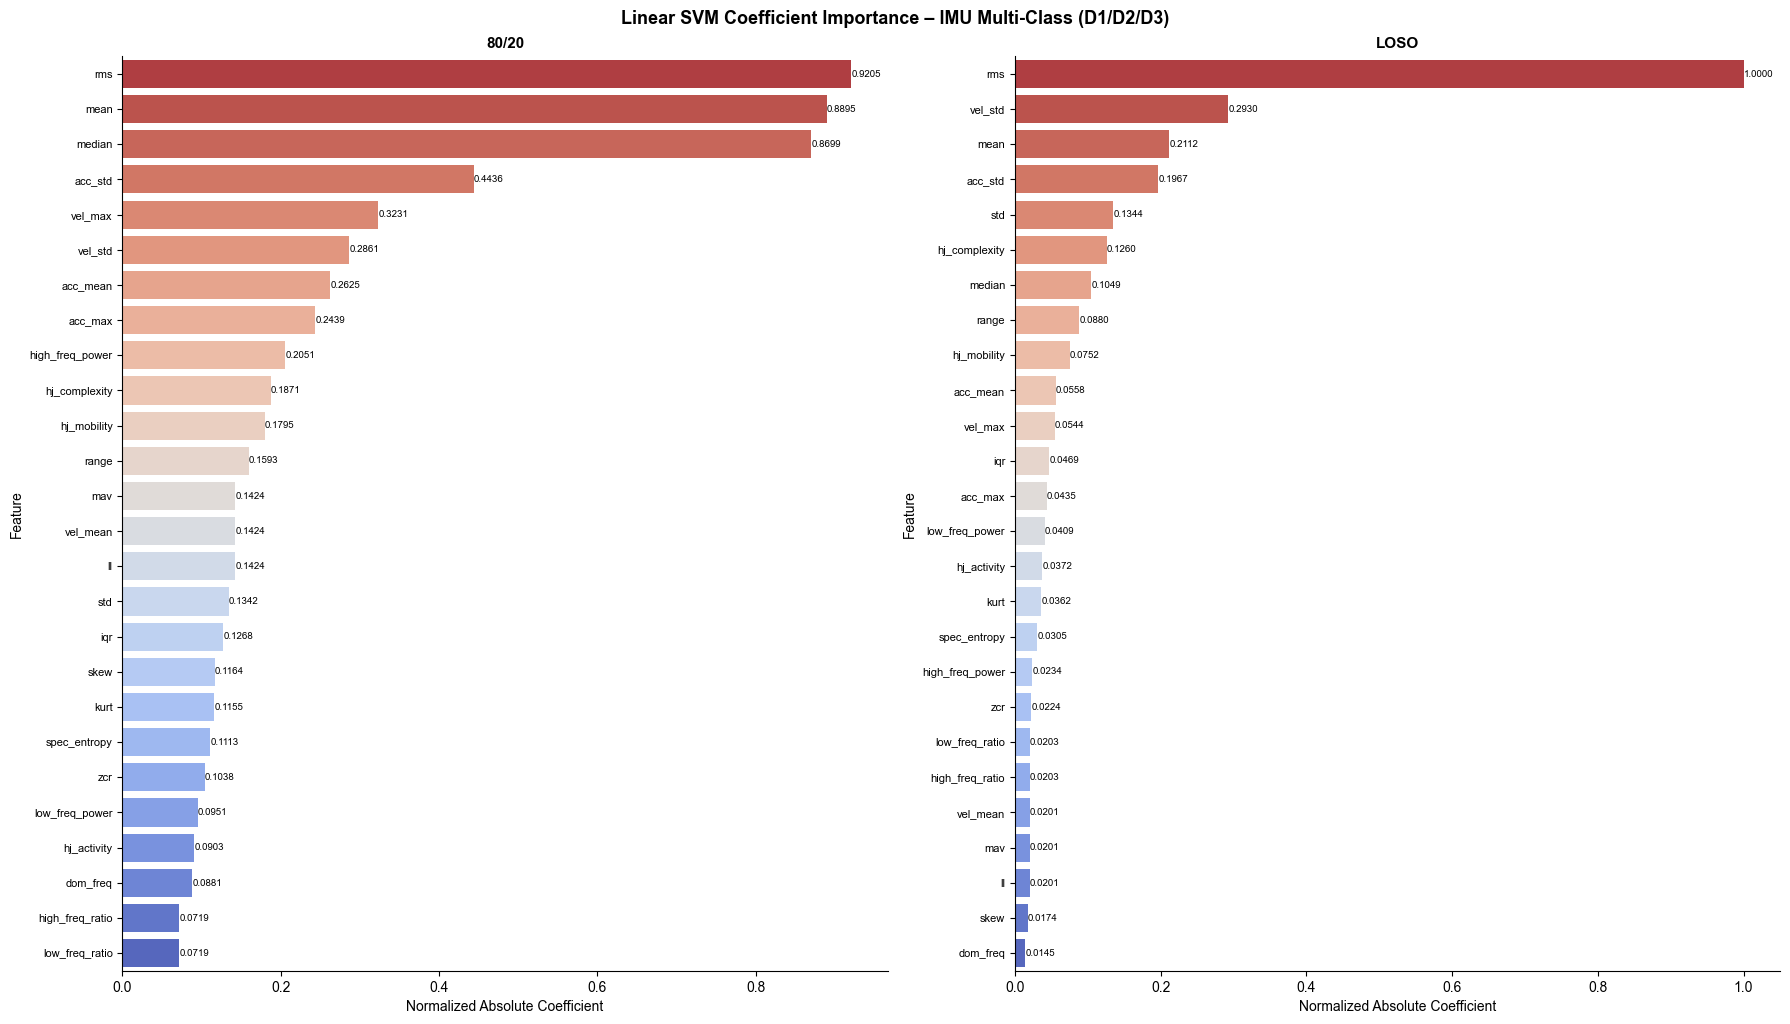


Saved to linear_svm_coef_importance_multiclass.csv

TASK 2: BINARY (D1 vs Slouch D2+D3)

LINEAR SVM – IMU Binary (D1 vs Slouch) – 80/20
Accuracy : 0.886
Macro F1 : 0.879

PER-CLASS METRICS – IMU Binary (D1 vs Slouch) – 80/20
  Class                 Precision     Recall         F1    Support
  ------------------------------------------------------------
  D1 (Good)                 0.849      0.852      0.850        721
  Slouch (D2+D3)            0.909      0.907      0.908       1174
  ------------------------------------------------------------
  Macro Avg                 0.879      0.879      0.879
  Accuracy                                        0.886

ABSOLUTE COEFFICIENTS (normalized) – IMU Binary (D1 vs Slouch) – 80/20
  rms                                 0.893708
  mean                                0.802815
  median                              0.764043
  acc_std                             0.456980
  vel_max                             0.290136
  vel_std                   

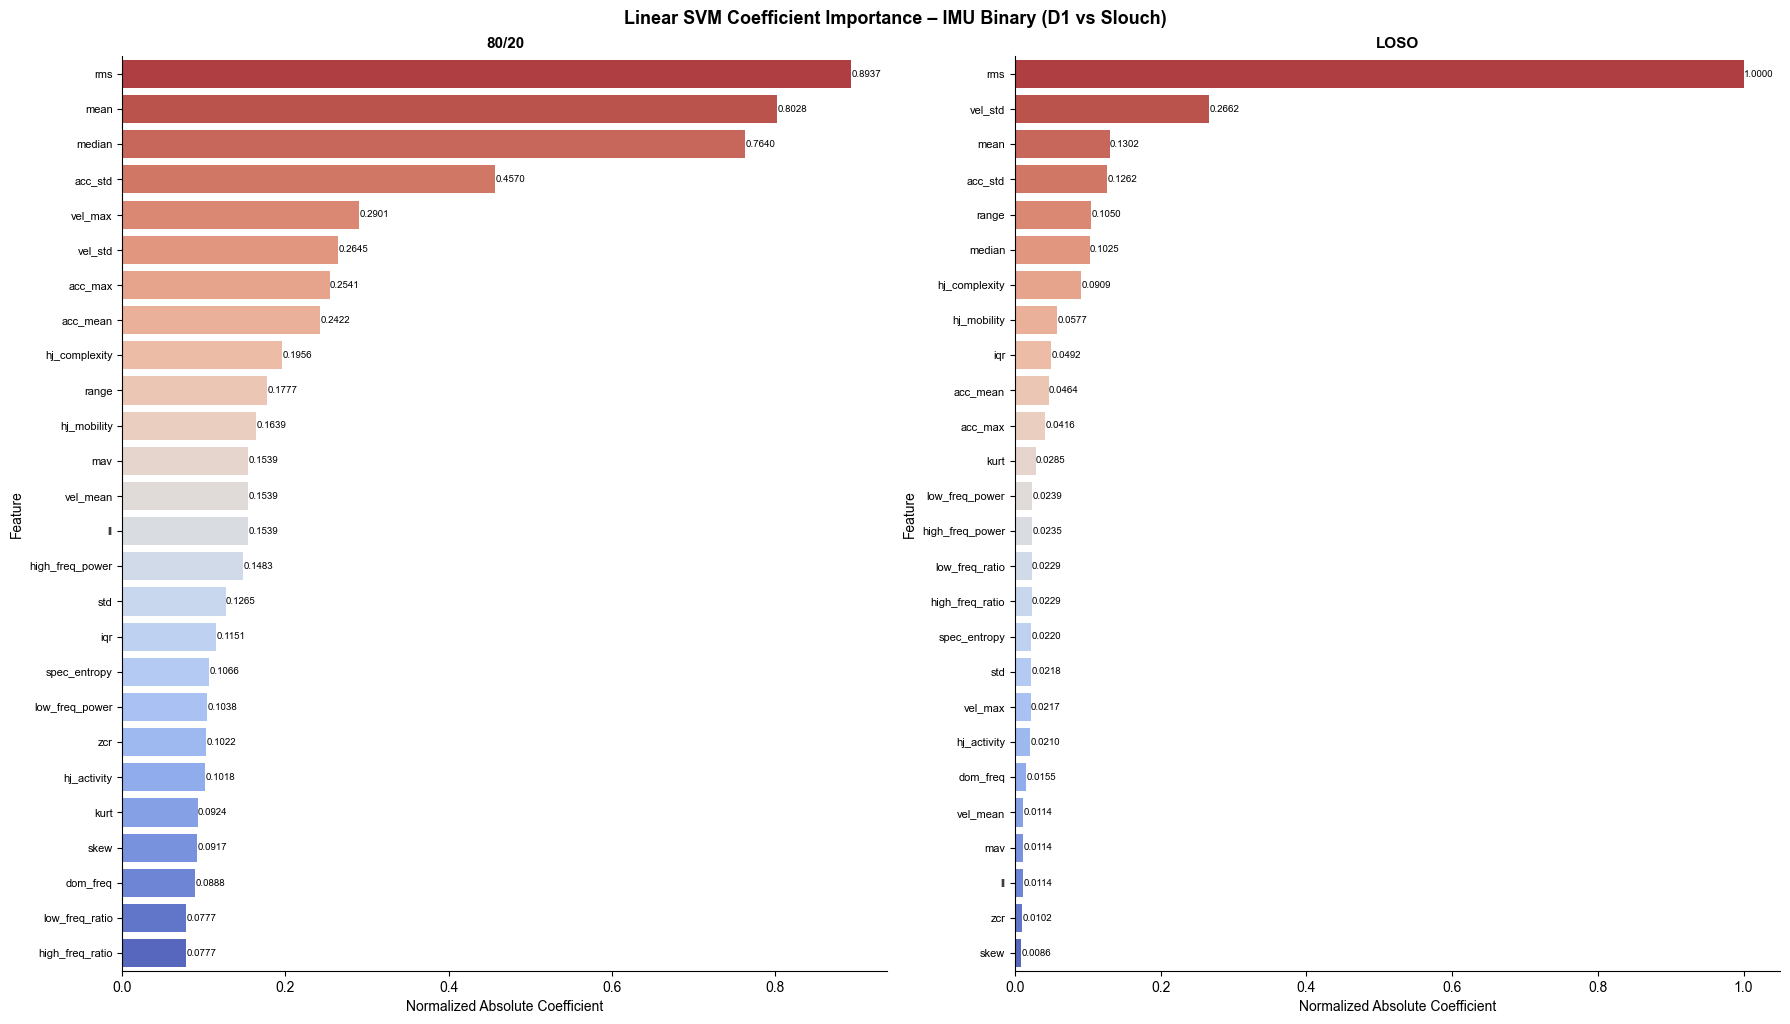


Saved to linear_svm_coef_importance_binary.csv

SUMMARY FOR PAPER
Binary Linear SVM  |  80/20 Acc: 0.886  Macro F1: 0.879
Binary Linear SVM  |  LOSO  Acc: 0.778  Macro F1: 0.773

Multiclass Linear SVM  |  80/20 Acc: 0.765  Macro F1: 0.751
Multiclass Linear SVM  |  LOSO  Acc: 0.634  Macro F1: 0.617

Use binary numbers in main paper.
Use multiclass numbers in appendix if needed.


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from collections import Counter

# ================= DEFINE LABELS =================
y_multi      = df_feat["label"].map({"d1": 0, "d2": 1, "d3": 2})
y_bin        = df_feat["label"].map({"d1": 0, "d2": 1, "d3": 1})
labels_multi = ["D1", "D2", "D3"]
labels_bin   = ["D1 (Good)", "Slouch (D2+D3)"]

# ================= HELPERS =================
def get_abs_coef_importance(model):
    """
    Coefficient-based importance for linear SVM.
    Binary: coef_.shape = (1, n_features)
    Multiclass OvO: average absolute coefficients across pairwise hyperplanes.
    Returns max-normalized absolute coefficients in [0, 1].
    """
    w = np.mean(np.abs(model.coef_), axis=0)
    if np.max(w) > 0:
        w = w / np.max(w)
    return w


def get_signed_binary_weights(model):
    """
    Signed coefficients for binary linear SVM only.
    Positive weight pushes toward class 1.
    Negative weight pushes toward class 0.
    """
    if model.coef_.shape[0] != 1:
        return None
    return model.coef_[0].copy()


def print_all_weights(weights, feat_cols, title, split, signed=False):
    if weights is None:
        return
    print(f"\n{'='*60}")
    label = "SIGNED WEIGHTS" if signed else "ABSOLUTE COEFFICIENTS (normalized)"
    print(f"{label} – {title} – {split}")
    print(f"{'='*60}")
    s = pd.Series(weights, index=feat_cols).sort_values(ascending=False)
    for f, v in s.items():
        print(f"  {f:<35s} {v:.6f}")


def print_top5(weights, feat_cols, title, split):
    if weights is None:
        return
    s = pd.Series(weights, index=feat_cols).sort_values(ascending=False)
    print(f"\nTop 5 Features – {title} – {split}:")
    for f, v in s.head(5).items():
        print(f"  {f:<35s} {v:.6f}")


def print_per_class_metrics(all_true, all_pred, labels, title, split):
    print(f"\n{'='*60}")
    print(f"PER-CLASS METRICS – {title} – {split}")
    print(f"{'='*60}")
    print(f"  {'Class':<20s} {'Precision':>10} {'Recall':>10} "
          f"{'F1':>10} {'Support':>10}")
    print(f"  {'-'*60}")

    prec    = precision_score(all_true, all_pred, average=None, zero_division=0)
    rec     = recall_score(all_true, all_pred, average=None, zero_division=0)
    f1      = f1_score(all_true, all_pred, average=None, zero_division=0)
    support = Counter(all_true)

    for i, lab in enumerate(labels):
        print(f"  {lab:<20s} {prec[i]:>10.3f} {rec[i]:>10.3f} "
              f"{f1[i]:>10.3f} {support[i]:>10d}")

    print(f"  {'-'*60}")
    macro_p = precision_score(all_true, all_pred, average="macro", zero_division=0)
    macro_r = recall_score(all_true, all_pred, average="macro", zero_division=0)
    macro_f = f1_score(all_true, all_pred, average="macro", zero_division=0)
    acc     = accuracy_score(all_true, all_pred)

    print(f"  {'Macro Avg':<20s} {macro_p:>10.3f} {macro_r:>10.3f} "
          f"{macro_f:>10.3f}")
    print(f"  {'Accuracy':<20s} {'':>10} {'':>10} {acc:>10.3f}")


# ================= 80/20 LINEAR SVM =================
def linear_svm_8020(df_feat, y_array, labels, title):
    """
    Participant-wise temporal 80/20 split.
    For each participant: first 80% = train, last 20% = test.
    Coefficient-based importance is averaged across valid participant folds.
    Returns:
        acc, macro_f1, avg_abs_weights, avg_signed_weights_or_None, feat_cols
    """
    feat_cols = [c for c in df_feat.columns if c not in ["participant", "label"]]

    all_true, all_pred  = [], []
    fold_abs_weights    = []
    fold_signed_weights = []
    is_binary           = (len(labels) == 2)

    for pid in df_feat["participant"].unique():
        sub = df_feat[df_feat["participant"] == pid]
        if len(sub) < 5:
            continue

        X_sub = sub[feat_cols].reset_index(drop=True)
        y_sub = y_array[sub.index].reset_index(drop=True)

        n         = len(X_sub)
        split_idx = int(0.8 * n)
        X_tr      = X_sub.iloc[:split_idx]
        X_te      = X_sub.iloc[split_idx:]
        y_tr      = y_sub.iloc[:split_idx]
        y_te      = y_sub.iloc[split_idx:]

        if len(np.unique(y_tr)) < len(labels):
            continue

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        model = SVC(
            kernel="linear",
            C=1.0,
            class_weight="balanced",
            random_state=42,
        )
        model.fit(X_tr_s, y_tr)
        y_hat = model.predict(X_te_s)

        all_true.append(y_te.values)
        all_pred.append(y_hat)

        abs_w = get_abs_coef_importance(model)
        fold_abs_weights.append(abs_w)

        if is_binary:
            signed_w = get_signed_binary_weights(model)
            fold_signed_weights.append(signed_w)

    if not all_true:
        print(f"[{title} 80/20] No valid folds.")
        return None, None, None, None, feat_cols

    all_true = np.concatenate(all_true)
    all_pred = np.concatenate(all_pred)
    acc      = accuracy_score(all_true, all_pred)
    macro_f1 = f1_score(all_true, all_pred, average="macro")

    avg_abs_weights = np.mean(np.vstack(fold_abs_weights), axis=0)
    avg_signed_weights = (
        np.mean(np.vstack(fold_signed_weights), axis=0)
        if is_binary and len(fold_signed_weights) > 0 else None
    )

    print(f"\n{'='*60}")
    print(f"LINEAR SVM – {title} – 80/20")
    print(f"{'='*60}")
    print(f"Accuracy : {acc:.3f}")
    print(f"Macro F1 : {macro_f1:.3f}")

    print_per_class_metrics(all_true, all_pred, labels, title, "80/20")
    print_all_weights(avg_abs_weights, feat_cols, title, "80/20", signed=False)
    print_top5(avg_abs_weights, feat_cols, title, "80/20")

    if avg_signed_weights is not None:
        print_all_weights(avg_signed_weights, feat_cols, title, "80/20", signed=True)

    return acc, macro_f1, avg_abs_weights, avg_signed_weights, feat_cols


# ================= LOSO LINEAR SVM =================
def linear_svm_loso(df_feat, y_array, labels, title):
    """
    Leave-one-subject-out evaluation.
    Scaler fitted on training fold only inside each fold.
    Coefficient-based importance is averaged across LOSO folds.
    Returns:
        acc, macro_f1, avg_abs_weights, avg_signed_weights_or_None, feat_cols
    """
    feat_cols = [c for c in df_feat.columns if c not in ["participant", "label"]]

    X      = df_feat[feat_cols].reset_index(drop=True)
    y      = y_array.reset_index(drop=True)
    groups = df_feat["participant"].reset_index(drop=True)

    all_true, all_pred  = [], []
    fold_abs_weights    = []
    fold_signed_weights = []
    is_binary           = (len(labels) == 2)

    logo = LeaveOneGroupOut()
    for train_idx, test_idx in logo.split(X, y, groups):
        X_tr = X.iloc[train_idx]
        X_te = X.iloc[test_idx]
        y_tr = y.iloc[train_idx]
        y_te = y.iloc[test_idx]

        if len(np.unique(y_tr)) < len(labels):
            continue

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        model = SVC(
            kernel="linear",
            C=1.0,
            class_weight="balanced",
            random_state=42,
        )
        model.fit(X_tr_s, y_tr)
        y_hat = model.predict(X_te_s)

        all_true.append(y_te.values)
        all_pred.append(y_hat)

        abs_w = get_abs_coef_importance(model)
        fold_abs_weights.append(abs_w)

        if is_binary:
            signed_w = get_signed_binary_weights(model)
            fold_signed_weights.append(signed_w)

    if not all_true:
        print(f"[{title} LOSO] No valid folds.")
        return None, None, None, None, feat_cols

    all_true = np.concatenate(all_true)
    all_pred = np.concatenate(all_pred)
    acc      = accuracy_score(all_true, all_pred)
    macro_f1 = f1_score(all_true, all_pred, average="macro")

    avg_abs_weights = np.mean(np.vstack(fold_abs_weights), axis=0)
    avg_signed_weights = (
        np.mean(np.vstack(fold_signed_weights), axis=0)
        if is_binary and len(fold_signed_weights) > 0 else None
    )

    print(f"\n{'='*60}")
    print(f"LINEAR SVM – {title} – LOSO")
    print(f"{'='*60}")
    print(f"Accuracy : {acc:.3f}")
    print(f"Macro F1 : {macro_f1:.3f}")

    print_per_class_metrics(all_true, all_pred, labels, title, "LOSO")
    print_all_weights(avg_abs_weights, feat_cols, title, "LOSO", signed=False)
    print_top5(avg_abs_weights, feat_cols, title, "LOSO")

    if avg_signed_weights is not None:
        print_all_weights(avg_signed_weights, feat_cols, title, "LOSO", signed=True)

    return acc, macro_f1, avg_abs_weights, avg_signed_weights, feat_cols


# ================= PLOT =================
def plot_weights(weights_8020, weights_loso, feat_cols, title):
    if weights_8020 is None and weights_loso is None:
        print(f"No weights to plot for {title}")
        return

    n_feats = len(feat_cols)
    fig, axes = plt.subplots(1, 2, figsize=(18, max(8, n_feats * 0.4)))
    fig.suptitle(
        f"Linear SVM Coefficient Importance – {title}",
        fontweight="bold", fontsize=13
    )

    for ax, weights, split in zip(axes, [weights_8020, weights_loso], ["80/20", "LOSO"]):
        if weights is None:
            ax.axis("off")
            ax.set_title(f"{split} – No Data")
            continue

        s = pd.Series(weights, index=feat_cols).sort_values(ascending=False)
        df_plot = pd.DataFrame({"feature": s.index, "weight": s.values})

        sns.barplot(
            data=df_plot,
            x="weight", y="feature",
            hue="feature",
            palette="coolwarm_r",
            legend=False,
            ax=ax
        )
        ax.set_title(f"{split}", fontweight="bold", fontsize=11)
        ax.set_xlabel("Normalized Absolute Coefficient", fontsize=10)
        ax.set_ylabel("Feature", fontsize=10)
        ax.tick_params(axis="y", labelsize=8)
        ax.spines[["top", "right"]].set_visible(False)

        for i, val in enumerate(s.values):
            ax.text(val + 0.0005, i, f"{val:.4f}", va="center", fontsize=7)

    plt.tight_layout()
    plt.show()


# ================= SAVE =================
def save_weights_csv(w_8020, w_loso, feat_cols, filename, signed_8020=None, signed_loso=None):
    df_out = pd.DataFrame({
        "feature": feat_cols,
        "norm_abs_coef_8020": w_8020 if w_8020 is not None else [np.nan] * len(feat_cols),
        "norm_abs_coef_loso": w_loso if w_loso is not None else [np.nan] * len(feat_cols),
    })
    if signed_8020 is not None:
        df_out["signed_coef_8020"] = signed_8020
    if signed_loso is not None:
        df_out["signed_coef_loso"] = signed_loso

    df_out = df_out.sort_values("norm_abs_coef_8020", ascending=False)
    df_out.to_csv(filename, index=False)
    print(f"\nSaved to {filename}")


# ================= RUN ALL FOUR TASKS =================

# --- TASK 1: MULTICLASS D1/D2/D3 ---
print("\n" + "="*60)
print("TASK 1: MULTICLASS (D1 / D2 / D3)")
print("="*60)

acc_m_8020, f1_m_8020, w_multi_8020, _, feat_cols = linear_svm_8020(
    df_feat=df_feat, y_array=y_multi,
    labels=labels_multi, title="IMU Multi-Class (D1/D2/D3)"
)
acc_m_loso, f1_m_loso, w_multi_loso, _, _ = linear_svm_loso(
    df_feat=df_feat, y_array=y_multi,
    labels=labels_multi, title="IMU Multi-Class (D1/D2/D3)"
)
plot_weights(
    w_multi_8020, w_multi_loso,
    feat_cols, title="IMU Multi-Class (D1/D2/D3)"
)
save_weights_csv(
    w_multi_8020, w_multi_loso,
    feat_cols, "linear_svm_coef_importance_multiclass.csv"
)

# --- TASK 2: BINARY D1 vs SLOUCH ---
print("\n" + "="*60)
print("TASK 2: BINARY (D1 vs Slouch D2+D3)")
print("="*60)

acc_b_8020, f1_b_8020, w_bin_8020, s_bin_8020, feat_cols = linear_svm_8020(
    df_feat=df_feat, y_array=y_bin,
    labels=labels_bin, title="IMU Binary (D1 vs Slouch)"
)
acc_b_loso, f1_b_loso, w_bin_loso, s_bin_loso, _ = linear_svm_loso(
    df_feat=df_feat, y_array=y_bin,
    labels=labels_bin, title="IMU Binary (D1 vs Slouch)"
)
plot_weights(
    w_bin_8020, w_bin_loso,
    feat_cols, title="IMU Binary (D1 vs Slouch)"
)
save_weights_csv(
    w_bin_8020, w_bin_loso,
    feat_cols, "linear_svm_coef_importance_binary.csv",
    signed_8020=s_bin_8020, signed_loso=s_bin_loso
)

# ================= SUMMARY FOR PAPER =================
print("\n" + "="*60)
print("SUMMARY FOR PAPER")
print("="*60)
print(f"Binary Linear SVM  |  80/20 Acc: {acc_b_8020:.3f}  Macro F1: {f1_b_8020:.3f}")
print(f"Binary Linear SVM  |  LOSO  Acc: {acc_b_loso:.3f}  Macro F1: {f1_b_loso:.3f}")
print(f"\nMulticlass Linear SVM  |  80/20 Acc: {acc_m_8020:.3f}  Macro F1: {f1_m_8020:.3f}")
print(f"Multiclass Linear SVM  |  LOSO  Acc: {acc_m_loso:.3f}  Macro F1: {f1_m_loso:.3f}")
print("\nUse binary numbers in main paper.")
print("Use multiclass numbers in appendix if needed.")

<h1>hyperparameter gridsearch </h1>

In [120]:
from pathlib import Path
import os
import re
import numpy as np
import pandas as pd
from itertools import product

from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

import warnings
warnings.filterwarnings("ignore")

# ================= CONFIG =================
IMU_FS       = 50
TRIM_SAMPLES = 10 * IMU_FS
WINDOW_SEC   = 5
OVERLAP      = 0.5
WIN_LEN      = int(WINDOW_SEC * IMU_FS)
STEP         = int(WIN_LEN * (1 - OVERLAP))

DERIVED_ROOT = Path("")
SAVE_CSV     = "imu_recording_grid_search_results.csv"

# ================= HELPERS =================
def get_metadata(path_str):
    parts         = path_str.split("/")
    participant   = parts[6] if len(parts) > 6 else "UNKNOWN"
    task          = parts[8] if len(parts) > 8 else "UNK_TASK"
    filename      = os.path.basename(path_str).lower()
    posture_match = re.search(r"d[1-3]", filename)
    posture       = posture_match.group(0) if posture_match else None
    return participant, task, posture


def hjorth_params(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 5:
        return {
            "hjorth_activity":   0.0,
            "hjorth_mobility":   0.0,
            "hjorth_complexity": 0.0,
        }
    dx      = np.diff(x)
    ddx     = np.diff(dx)
    var_x   = np.var(x)
    var_dx  = np.var(dx)
    var_ddx = np.var(ddx)
    activity   = var_x
    mobility   = np.sqrt(var_dx  / (var_x  + 1e-12))
    complexity = np.sqrt(
        (var_ddx / (var_dx + 1e-12)) / (var_dx / (var_x + 1e-12) + 1e-12)
    )
    return {
        "hjorth_activity":   float(activity),
        "hjorth_mobility":   float(mobility),
        "hjorth_complexity": float(complexity),
    }


def spectral_entropy(psd):
    psd = np.asarray(psd, dtype=float)
    psd = psd[np.isfinite(psd)]
    if psd.size == 0:
        return 0.0
    p = psd / (psd.sum() + 1e-12)
    return float(-np.sum(p * np.log2(p + 1e-12)))


# ================= DATA LOADING =================
def load_data():
    imu_files = list(DERIVED_ROOT.rglob("imu/**/*.csv"))
    print(f"IMU files found: {len(imu_files)}")

    records = []
    for path in imu_files:
        path_str = str(path)
        p, task, post = get_metadata(path_str)

        if post not in {"d1", "d2", "d3"}:
            continue

        df = pd.read_csv(path_str)
        if "Pitch" not in df.columns:
            continue

        pitch = df["Pitch"].values.astype(float)
        if len(pitch) <= TRIM_SAMPLES:
            continue

        pitch = pitch[TRIM_SAMPLES:]

        records.append({
            "participant": p,
            "task":        task,
            "posture":     post,
            "sig":         pitch,
            "path":        path_str,
        })

    df_norm = pd.DataFrame(records)
    print(f"Records loaded: {len(df_norm)}")
    return df_norm


# ================= BASELINE CENTERING =================
def baseline_center(df_norm):
    baselines = (
        df_norm[df_norm["posture"] == "d1"]
        .groupby("participant")["sig"]
        .apply(lambda s: np.median(np.concatenate(s.values)))
        .to_dict()
    )

    print("\nParticipant baselines (deg):")
    for p, b in baselines.items():
        print(f"  {p}: {b:.2f}")

    df_norm["P_base"]   = df_norm["participant"].map(baselines)
    df_norm["norm_sig"] = df_norm.apply(
        lambda r: r["sig"] - r["P_base"] if r["P_base"] is not None else r["sig"],
        axis=1,
    )
    return df_norm


# ================= WINDOW-LEVEL IMU FEATURES =================
def extract_features_from_window(w):
    mean_w   = float(np.mean(w))
    median_w = float(np.median(w))
    std_w    = float(np.std(w))
    rms_w    = float(np.sqrt(np.mean(w ** 2)))
    range_w  = float(np.ptp(w))
    iqr_w    = float(np.percentile(w, 75) - np.percentile(w, 25))
    skew_w   = float(skew(w))     if len(w) > 10 else 0.0
    kurt_w   = float(kurtosis(w)) if len(w) > 10 else 0.0

    vel   = np.diff(w) * IMU_FS
    mav_w = float(np.mean(np.abs(vel))) if len(vel) > 0 else 0.0

    acc      = np.diff(vel) * IMU_FS if len(vel) > 1 else np.array([])
    acc_mean = float(np.mean(np.abs(acc))) if len(acc) > 0 else 0.0
    acc_std  = float(np.std(acc))           if len(acc) > 0 else 0.0
    acc_max  = float(np.max(np.abs(acc)))   if len(acc) > 0 else 0.0

    zc = (
        float(np.sum(np.diff(np.sign(w - mean_w)) != 0) / len(w))
        if len(w) > 1 else 0.0
    )
    ll = float(np.sum(np.abs(np.diff(w)))) if len(w) > 1 else 0.0

    hj = hjorth_params(w)

    n = len(w)
    if n >= 64:
        w_d   = w - mean_w
        yf    = np.fft.fft(w_d)
        xf    = np.fft.fftfreq(n, 1 / IMU_FS)[:n // 2]
        power = np.abs(yf[:n // 2]) ** 2

        dom_freq = (
            float(xf[int(np.argmax(power))])
            if power.size > 0 and np.max(power) > 0 else 0.0
        )
        spec_ent = spectral_entropy(power)

        low_mask   = xf < 1.0
        high_mask  = xf >= 1.0
        low_power  = float(np.sum(power[low_mask]))  if np.any(low_mask)  else 0.0
        high_power = float(np.sum(power[high_mask])) if np.any(high_mask) else 0.0
        total_pow  = low_power + high_power + 1e-12
        low_freq_ratio  = low_power  / total_pow
        high_freq_ratio = high_power / total_pow
    else:
        dom_freq        = 0.0
        spec_ent        = 0.0
        low_power       = 0.0
        high_power      = 0.0
        low_freq_ratio  = 0.0
        high_freq_ratio = 0.0

    return {
        "mean":            mean_w,
        "median":          median_w,
        "std":             std_w,
        "rms":             rms_w,
        "range":           range_w,
        "skew":            skew_w,
        "kurt":            kurt_w,
        "iqr":             iqr_w,
        "mav":             mav_w,
        "zcr":             zc,
        "ll":              ll,
        "vel_mean":        float(np.mean(np.abs(vel))) if len(vel) > 0 else 0.0,
        "vel_std":         float(np.std(vel))          if len(vel) > 0 else 0.0,
        "vel_max":         float(np.max(np.abs(vel)))  if len(vel) > 0 else 0.0,
        "acc_mean":        acc_mean,
        "acc_std":         acc_std,
        "acc_max":         acc_max,
        "hj_activity":     hj["hjorth_activity"],
        "hj_mobility":     hj["hjorth_mobility"],
        "hj_complexity":   hj["hjorth_complexity"],
        "dom_freq":        dom_freq,
        "spec_entropy":    spec_ent,
        "low_freq_power":  low_power,
        "high_freq_power": high_power,
        "low_freq_ratio":  low_freq_ratio,
        "high_freq_ratio": high_freq_ratio,
    }


# ================= RECORDING-LEVEL AGGREGATION =================
def extract_features_per_recording(row):
    sig = row["norm_sig"]
    if len(sig) < WIN_LEN:
        return None

    starts = np.arange(0, len(sig) - WIN_LEN + 1, STEP)
    if len(starts) == 0:
        return None

    window_features = []
    for start in starts:
        w     = sig[start:start + WIN_LEN]
        feats = extract_features_from_window(w)
        window_features.append(feats)

    if not window_features:
        return None

    keys     = list(window_features[0].keys())
    avg_feat = {k: float(np.mean([wf[k] for wf in window_features])) for k in keys}
    return avg_feat


def build_dataset(df_norm):
    rows = []
    for _, row in df_norm.iterrows():
        feat = extract_features_per_recording(row)
        if feat is None:
            continue
        rows.append({
            "Participant": row["participant"],
            "Posture":     row["posture"],
            **feat,
        })
    df = pd.DataFrame(rows)
    print(f"Recordings with features: {len(df)}")
    return df


# ================= LOSO EVALUATION =================
def evaluate_pipeline(pipeline, X, y, groups):
    """
    Manual LOSO — pipeline contains imputer+scaler+clf so all
    preprocessing is fit only on training folds. No data leakage.
    """
    logo      = LeaveOneGroupOut()
    y_true_all = []
    y_pred_all = []
    n_classes  = len(np.unique(y))

    for train_idx, test_idx in logo.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        if len(np.unique(y_tr)) < n_classes:
            continue

        pipeline.fit(X_tr, y_tr)
        y_pred = pipeline.predict(X_te)

        y_true_all.extend(y_te)
        y_pred_all.extend(y_pred)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    acc  = accuracy_score(y_true_all,  y_pred_all)
    prec = precision_score(y_true_all,  y_pred_all, average="macro", zero_division=0)
    rec  = recall_score(y_true_all,     y_pred_all, average="macro", zero_division=0)
    f1   = f1_score(y_true_all,         y_pred_all, average="macro", zero_division=0)

    return acc, prec, rec, f1


# ================= GRID SEARCH =================
def run_grid(model_name, param_grid, clf_constructor, clf_fixed_kwargs,
             X, y, groups, task_label, all_results):

    keys   = list(param_grid.keys())
    combos = list(product(*param_grid.values()))
    total  = len(combos)
    print(f"\n  {model_name} [{task_label}]: {total} combinations")

    for i, combo in enumerate(combos, 1):
        tunable    = dict(zip(keys, combo))
        all_kwargs = {**tunable, **clf_fixed_kwargs}

        # imputer first so NaNs from short recordings are handled
        # before scaler and classifier — all fit on training fold only
        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler",  StandardScaler()),
            ("clf",     clf_constructor(**all_kwargs)),
        ])

        acc, prec, rec, f1 = evaluate_pipeline(pipeline, X, y, groups)

        param_str = "  ".join(f"{k}={v}" for k, v in tunable.items())
        print(
            f"    [{i:>3}/{total}] {param_str} | "
            f"Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}"
        )

        all_results.append({
            "model":     model_name,
            "task":      task_label,
            **tunable,
            "accuracy":  round(acc,  4),
            "precision": round(prec, 4),
            "recall":    round(rec,  4),
            "f1":        round(f1,   4),
        })

    # checkpoint after every model+task block
    pd.DataFrame(all_results).to_csv(SAVE_CSV, index=False)
    print(f"  --> checkpoint saved ({len(all_results)} rows so far)")


# ================= SUMMARY =================
def print_summary(df_results):
    skip_cols = {"model", "task", "accuracy", "precision", "recall", "f1"}
    print("\n" + "=" * 72)
    print("BEST CONFIG PER MODEL + TASK  (ranked by macro F1)")
    print("=" * 72)

    for task_label in ["binary", "multiclass"]:
        print(f"\n--- {task_label.upper()} ---")
        for model_name in ["GB", "RF", "RBF_SVM", "LinearSVM"]:
            subset = df_results[
                (df_results["model"] == model_name) &
                (df_results["task"]  == task_label)
            ]
            if subset.empty:
                continue

            best      = subset.loc[subset["f1"].idxmax()]
            param_str = ", ".join(
                f"{c}={best[c]}"
                for c in best.index
                if c not in skip_cols and pd.notna(best[c])
            )
            print(
                f"  {model_name:12s} | "
                f"Acc={best['accuracy']:.3f}  "
                f"Prec={best['precision']:.3f}  "
                f"Rec={best['recall']:.3f}  "
                f"F1={best['f1']:.3f}  "
                f"[{param_str}]"
            )


def print_match_check(df_results):
    """Compare grid best against paper-selected parameters."""
    current = {
        ("GB",        "binary"):      {"n_estimators": 200, "learning_rate": 0.1, "max_depth": 3},
        ("GB",        "multiclass"):  {"n_estimators": 200, "learning_rate": 0.1, "max_depth": 3},
        ("RF",        "binary"):      {"n_estimators": 300, "max_depth": 10, "min_samples_leaf": 5},
        ("RF",        "multiclass"):  {"n_estimators": 300, "max_depth": 10, "min_samples_leaf": 5},
        ("RBF_SVM",   "binary"):      {"C": 1.0, "gamma": "scale"},
        ("RBF_SVM",   "multiclass"):  {"C": 1.0, "gamma": "scale"},
        ("LinearSVM", "binary"):      {"C": 1.0},
        ("LinearSVM", "multiclass"):  {"C": 1.0},
    }

    skip_cols = {"model", "task", "accuracy", "precision", "recall", "f1"}
    print("\n" + "=" * 72)
    print("MATCH CHECK AGAINST CURRENTLY SELECTED PARAMETERS")
    print("=" * 72)

    for (model_name, task_label), cur in current.items():
        subset = df_results[
            (df_results["model"] == model_name) &
            (df_results["task"]  == task_label)
        ]
        if subset.empty:
            continue

        best        = subset.loc[subset["f1"].idxmax()]
        best_params = {
            c: best[c] for c in best.index
            if c not in skip_cols and pd.notna(best[c])
        }

        print(f"\n{model_name} [{task_label}]")
        print(f"  Current : {cur}")
        print(f"  Best    : {best_params}")

        mismatches = [
            (k, v, best_params.get(k))
            for k, v in cur.items()
            if best_params.get(k) != v
        ]
        if not mismatches:
            print("  Status  : MATCH")
        else:
            print("  Status  : MISMATCH")
            for k, old_v, new_v in mismatches:
                print(f"    {k}: current={old_v}  best={new_v}")


# ================= MAIN =================
def main():

    # 1. load
    df_norm = load_data()
    if df_norm.empty:
        print("No valid IMU data found.")
        return

    # 2. baseline center
    df_norm = baseline_center(df_norm)

    # 3. build recording-level features
    df_features = build_dataset(df_norm)
    if df_features.empty:
        print("Feature dataframe is empty. Exiting.")
        return

    # 4. prepare arrays
    feature_cols = [c for c in df_features.columns if c not in ["Participant", "Posture"]]
    X       = df_features[feature_cols].values
    y_bin   = df_features["Posture"].map({"d1": 0, "d2": 1, "d3": 1}).values
    y_multi = df_features["Posture"].map({"d1": 0, "d2": 1, "d3": 2}).values
    groups  = df_features["Participant"].values

    all_results = []

    # ---------------------------------------------------------------
    # GB
    # ---------------------------------------------------------------
    print("\n" + "=" * 60)
    print("GB GRID SEARCH")
    print("=" * 60)
    gb_grid = {
        "n_estimators":  [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "max_depth":     [2, 3, 5],
    }
    gb_fixed = {"random_state": 42}

    for task_label, y in [("binary", y_bin), ("multiclass", y_multi)]:
        run_grid("GB", gb_grid, GradientBoostingClassifier,
                 gb_fixed, X, y, groups, task_label, all_results)

    # ---------------------------------------------------------------
    # RF
    # ---------------------------------------------------------------
    print("\n" + "=" * 60)
    print("RF GRID SEARCH")
    print("=" * 60)
    rf_grid = {
        "n_estimators":     [100, 200, 300, 500],
        "max_depth":        [5, 8, 10, None],
        "min_samples_leaf": [1, 3, 5, 8],
    }
    rf_fixed = {
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs":       -1,
    }

    for task_label, y in [("binary", y_bin), ("multiclass", y_multi)]:
        run_grid("RF", rf_grid, RandomForestClassifier,
                 rf_fixed, X, y, groups, task_label, all_results)

    # ---------------------------------------------------------------
    # RBF SVM
    # ---------------------------------------------------------------
    print("\n" + "=" * 60)
    print("RBF SVM GRID SEARCH")
    print("=" * 60)
    rbf_grid = {
        "C":     [0.1, 1.0, 10.0],
        "gamma": ["scale", "auto", 0.01],
    }
    rbf_fixed = {
        "kernel":       "rbf",
        "class_weight": "balanced",
        "random_state": 42,
    }

    for task_label, y in [("binary", y_bin), ("multiclass", y_multi)]:
        run_grid("RBF_SVM", rbf_grid, SVC,
                 rbf_fixed, X, y, groups, task_label, all_results)

    # ---------------------------------------------------------------
    # Linear SVM
    # ---------------------------------------------------------------
    print("\n" + "=" * 60)
    print("LINEAR SVM GRID SEARCH")
    print("=" * 60)
    linear_grid = {
        "C": [0.01, 0.1, 1.0, 10.0],
    }
    linear_fixed = {
        "kernel":       "linear",
        "class_weight": "balanced",
        "random_state": 42,
    }

    for task_label, y in [("binary", y_bin), ("multiclass", y_multi)]:
        run_grid("LinearSVM", linear_grid, SVC,
                 linear_fixed, X, y, groups, task_label, all_results)

    # final save
    df_results = pd.DataFrame(all_results)
    df_results.to_csv(SAVE_CSV, index=False)
    print(f"\nFinal results saved to {SAVE_CSV}")

    # summaries
    print_summary(df_results)
    print_match_check(df_results)


if __name__ == "__main__":
    main()

IMU files found: 152
Records loaded: 152

Participant baselines (deg):
  AZIZ: -61.74
  Abhay: 49.97
  Ankur: -23.81
  Arghya: -13.88
  Arindam: 12.34
  Ario: 6.99
  Bhawana: 8.45
  Dip: 7.96
  Ishita: 60.54
  KOUSHIK: -65.02
  Krishna: 64.09
  Moly: 22.58
  Orchi: -5.01
  Postdoc: -3.33
  Prasun: -5.65
  Pritam: -7.30
  Riddho: 23.16
  SHAEKH: -79.17
  Sadia: 11.72
  Shruti: -1.68
  Tammy: 34.80
  Walid: 15.97
  mannz: 10.24
  monon: 9.01
Recordings with features: 152

GB GRID SEARCH

  GB [binary]: 36 combinations
    [  1/36] n_estimators=100  learning_rate=0.01  max_depth=2 | Acc=0.770  Prec=0.745  Rec=0.733  F1=0.738
    [  2/36] n_estimators=100  learning_rate=0.01  max_depth=3 | Acc=0.763  Prec=0.737  Rec=0.732  F1=0.734
    [  3/36] n_estimators=100  learning_rate=0.01  max_depth=5 | Acc=0.770  Prec=0.746  Rec=0.756  F1=0.750
    [  4/36] n_estimators=100  learning_rate=0.05  max_depth=2 | Acc=0.743  Prec=0.716  Rec=0.722  F1=0.719
    [  5/36] n_estimators=100  learning_rate=0